### XGBoost Model 

wandb: WARNING Failed to create global config settings in: /Users/komalwavhal/.config/wandb. Settings will not be persisted.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/komalwavhal/.netrc
wandb: Currently logged in as: mc77chand (mc77chand-stevens-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Users/komalwavhal/Documents/Anaconda_Software/anaconda3/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


✅ Loaded 23180369 rows from 1 files


/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_58894/622667181.py:99: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")


✅ Hourly dataset size: 2392762 rows
Train shape: (632483, 16), Test shape: (1760279, 16)

📅 TRAIN DATE RANGE
Start: 2015-03-03 15:00:00
End  : 2016-07-29 22:00:00

📅 TEST DATE RANGE
Start: 2017-06-22 15:00:00
End  : 2019-04-29 18:00:00
✅ XGBoost training complete

Evaluation Metrics:
xgb_avail_bikes_RMSE: 2.0903
xgb_avail_bikes_MAE: 1.1783
xgb_avail_bikes_R2: 0.9571
xgb_avail_bikes_MAPE: 23.1923
xgb_avail_docks_RMSE: 3.0933
xgb_avail_docks_MAE: 1.8104
xgb_avail_docks_R2: 0.9402
xgb_avail_docks_MAPE: 22.4639
xgb_occupancy_RMSE: 0.0613
xgb_occupancy_MAE: 0.0366
xgb_occupancy_R2: 0.9594
xgb_occupancy_MAPE: 22.7577


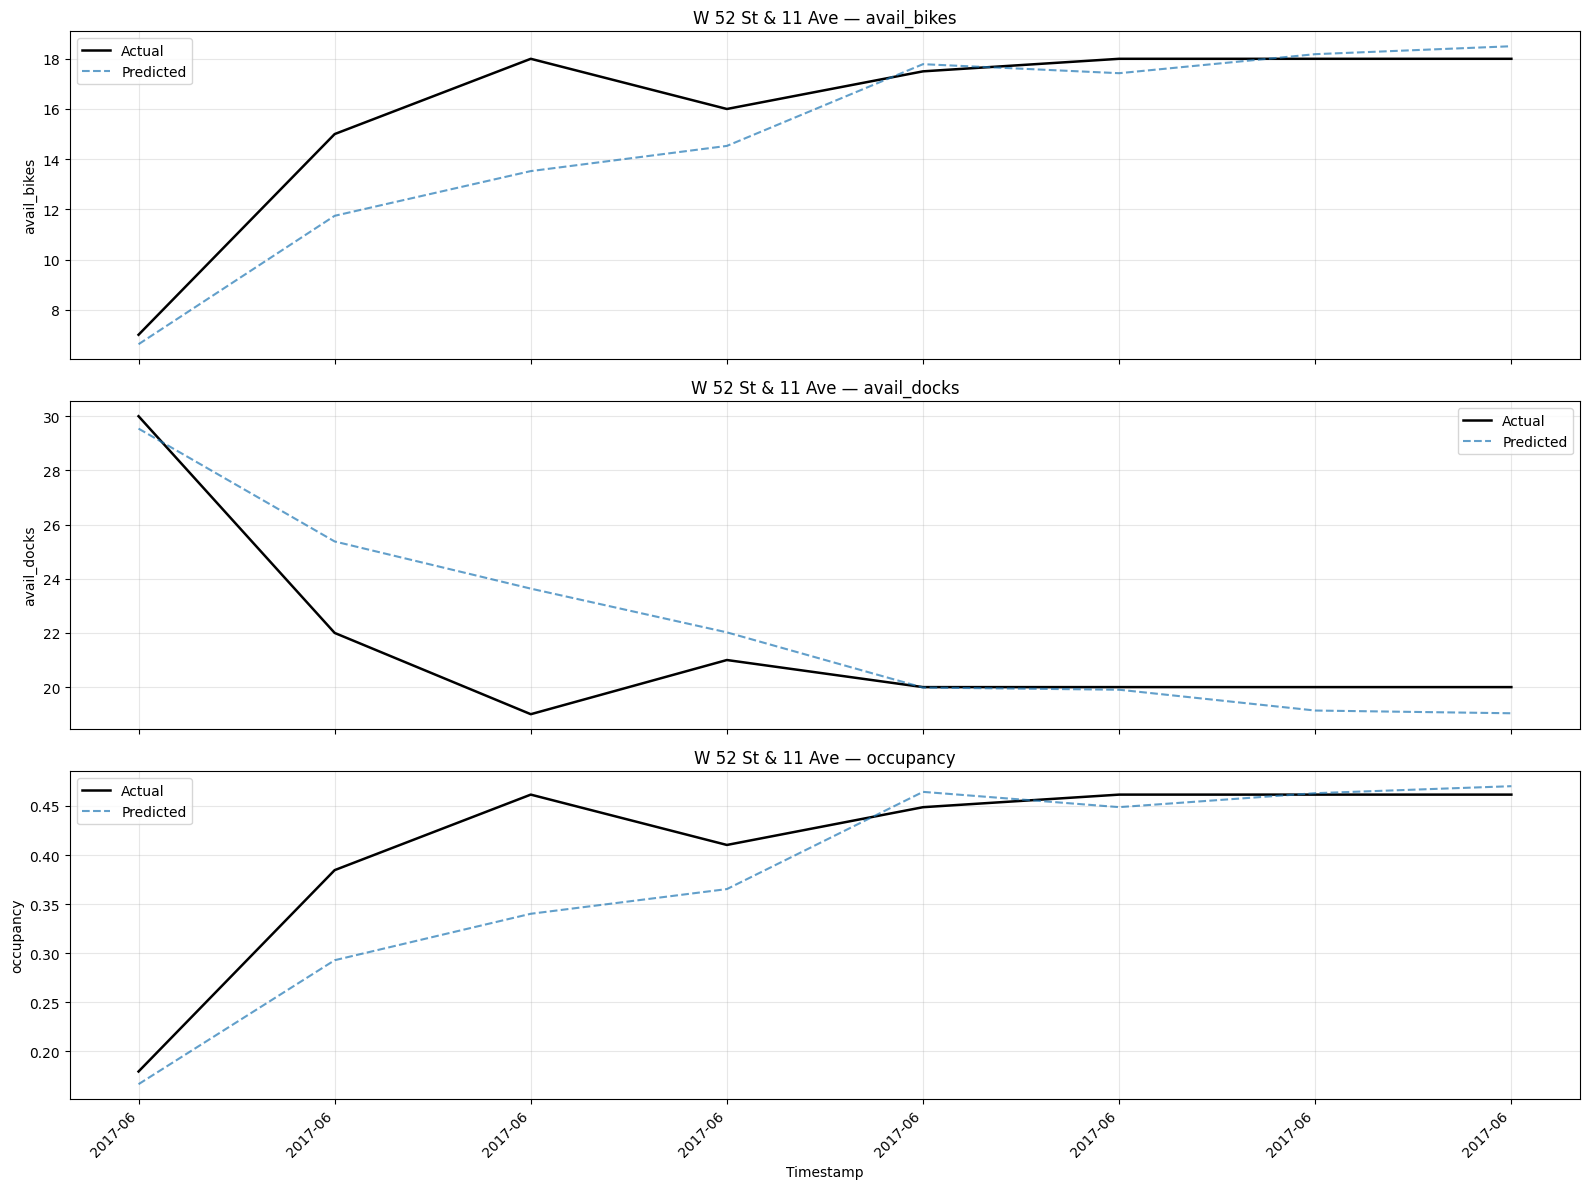

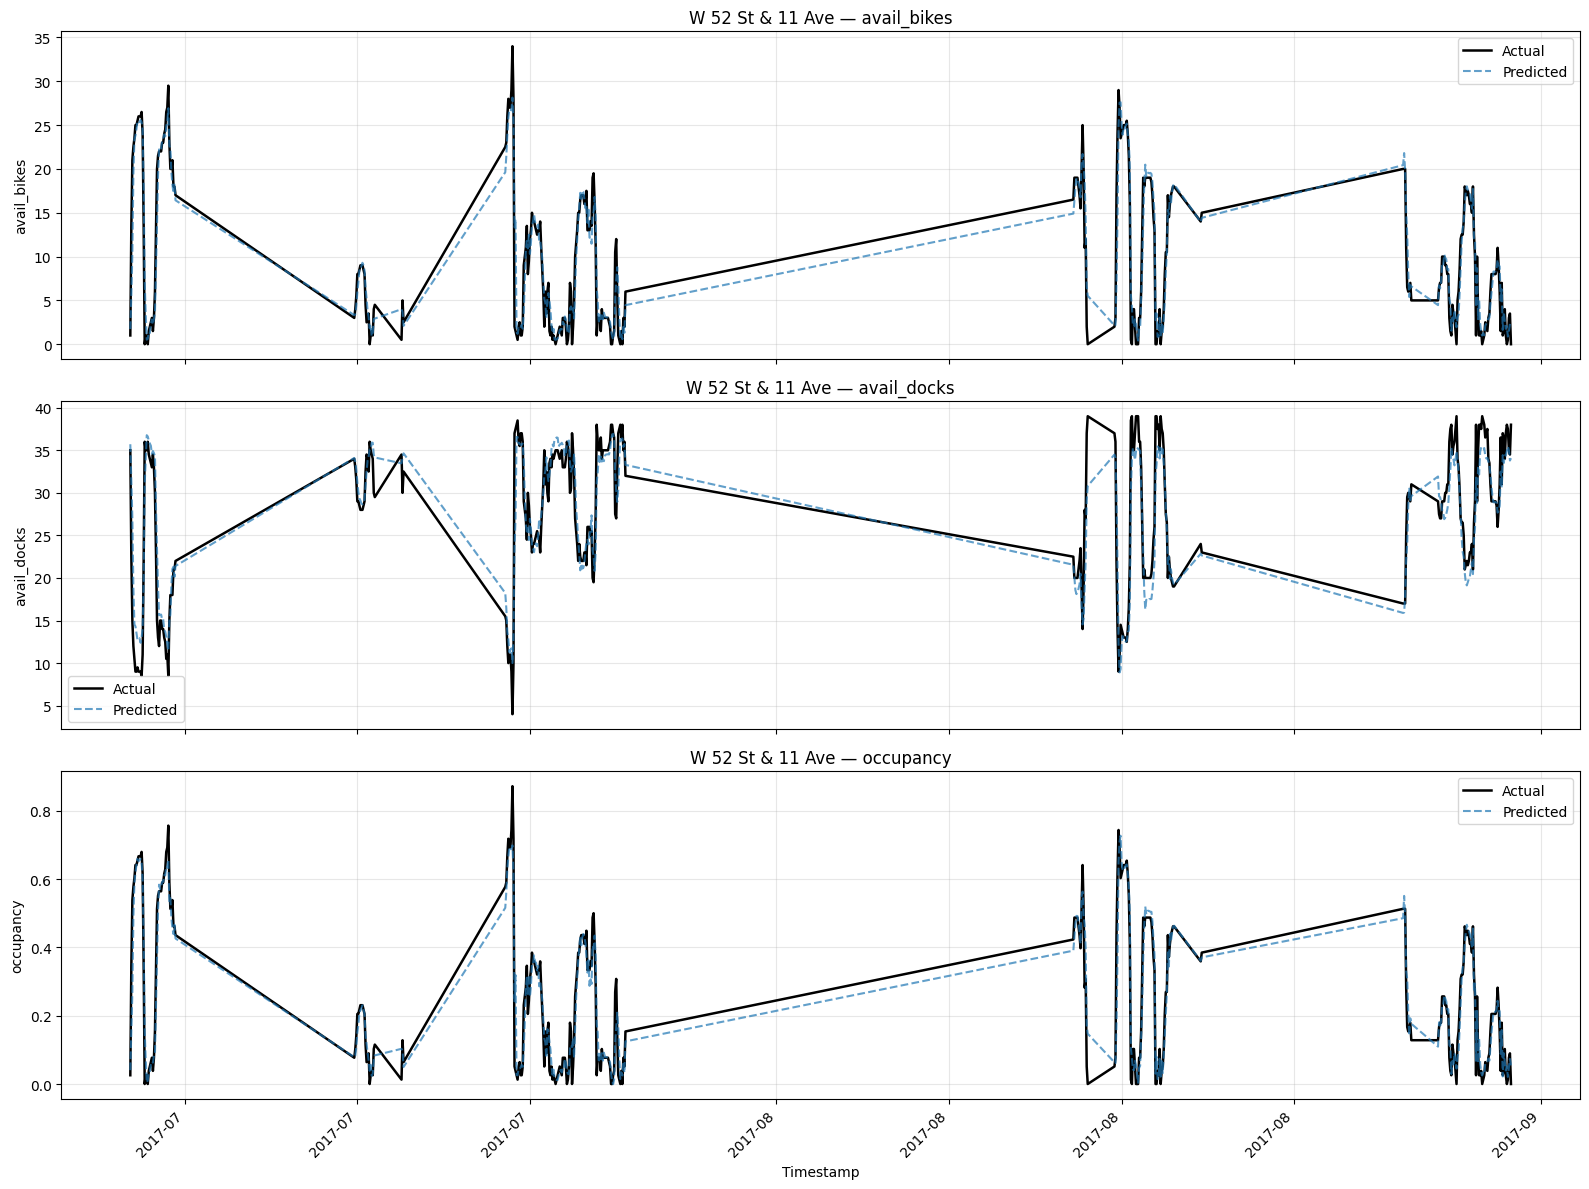

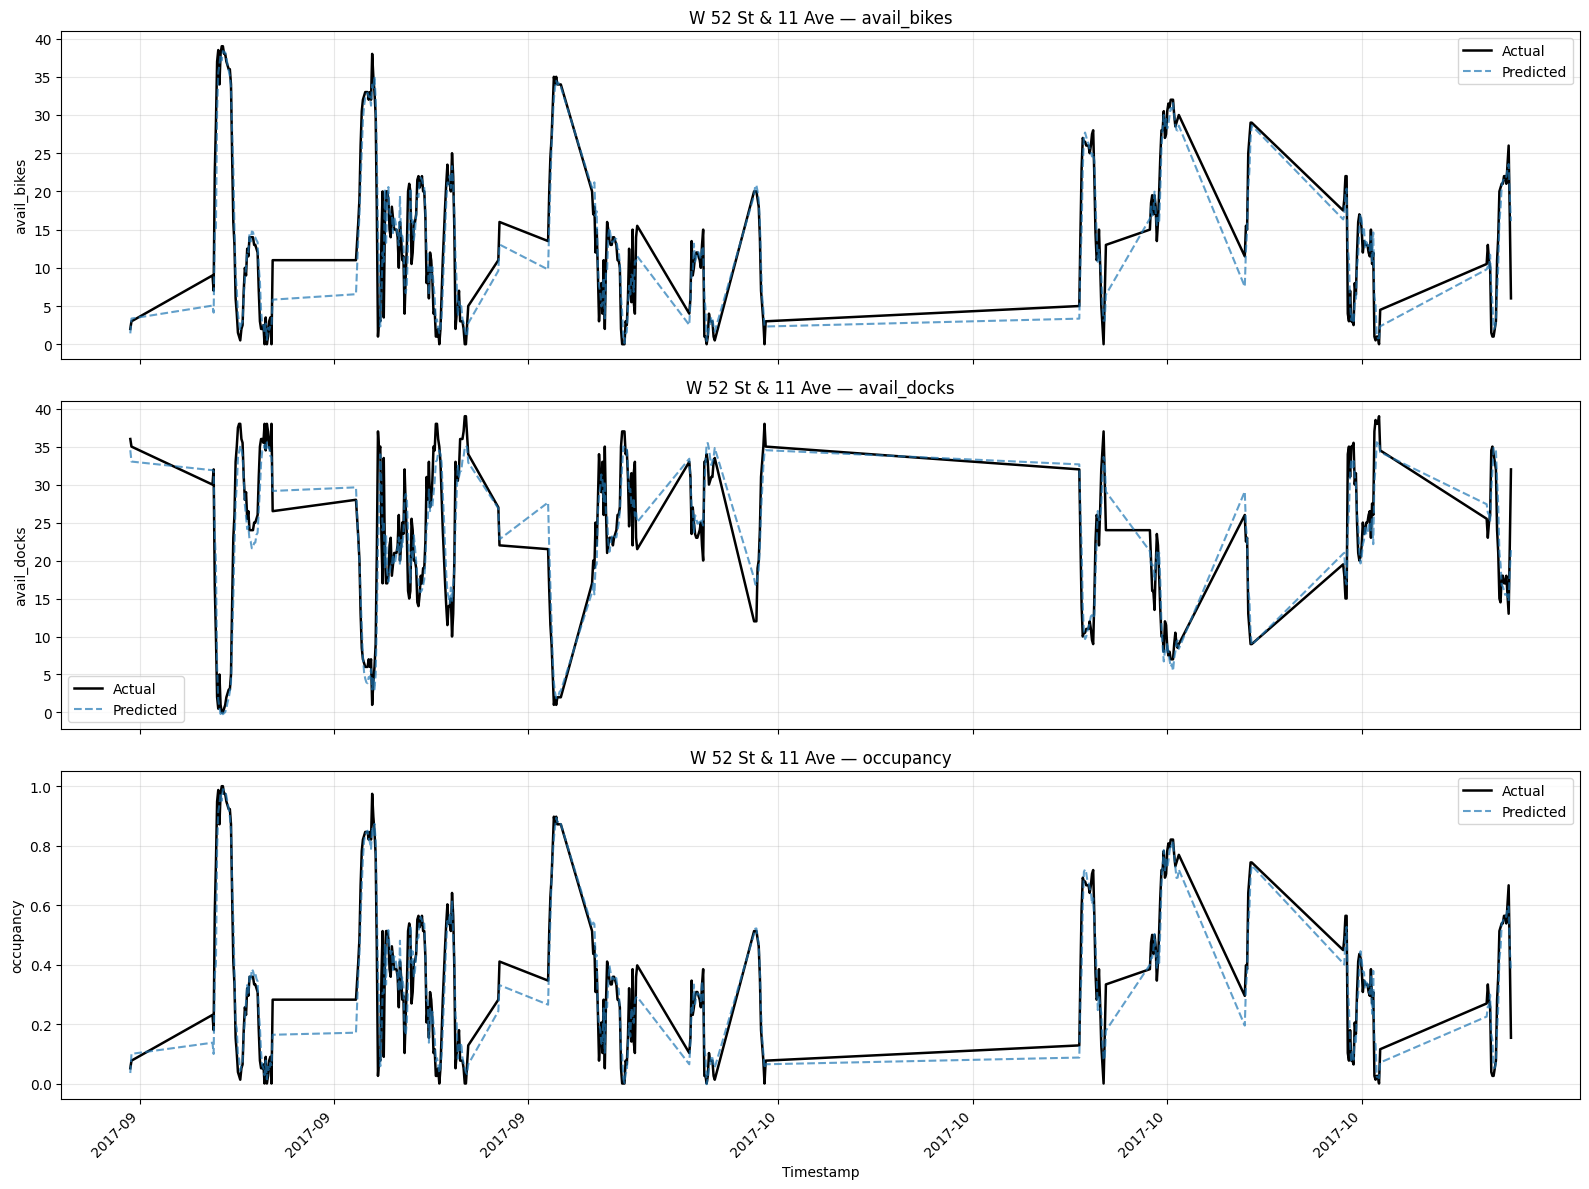

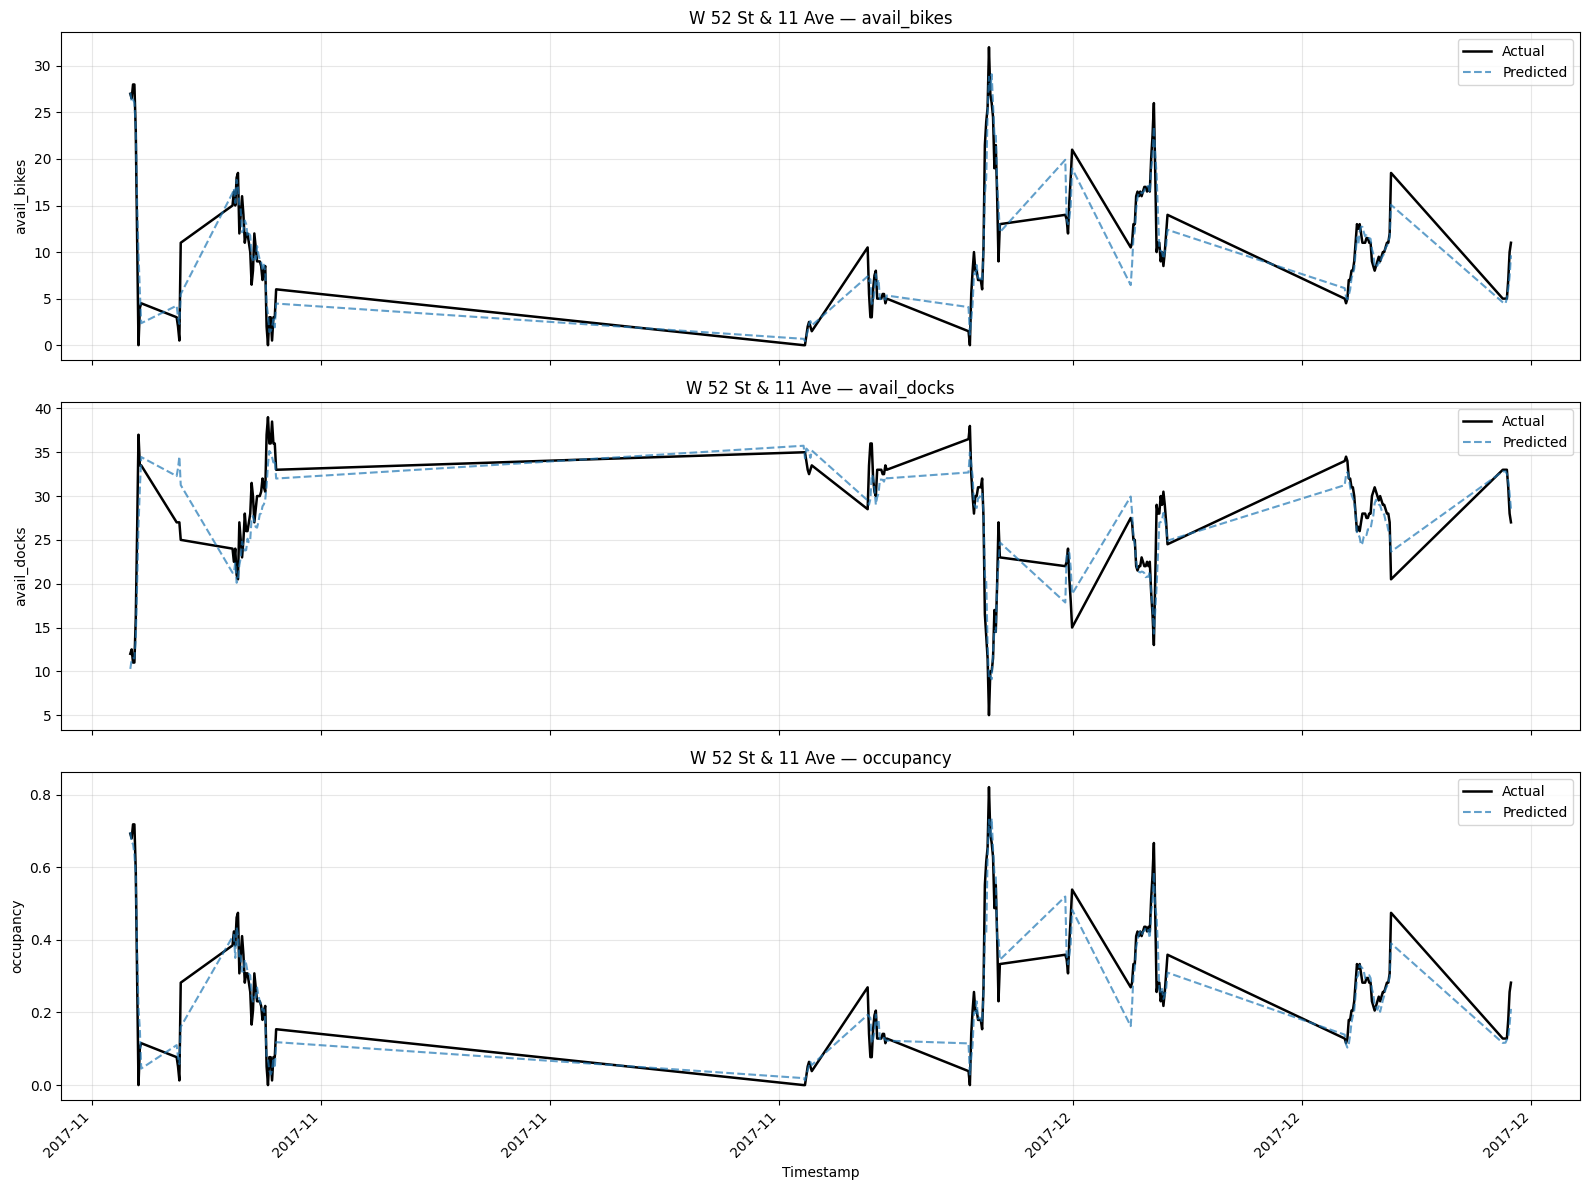

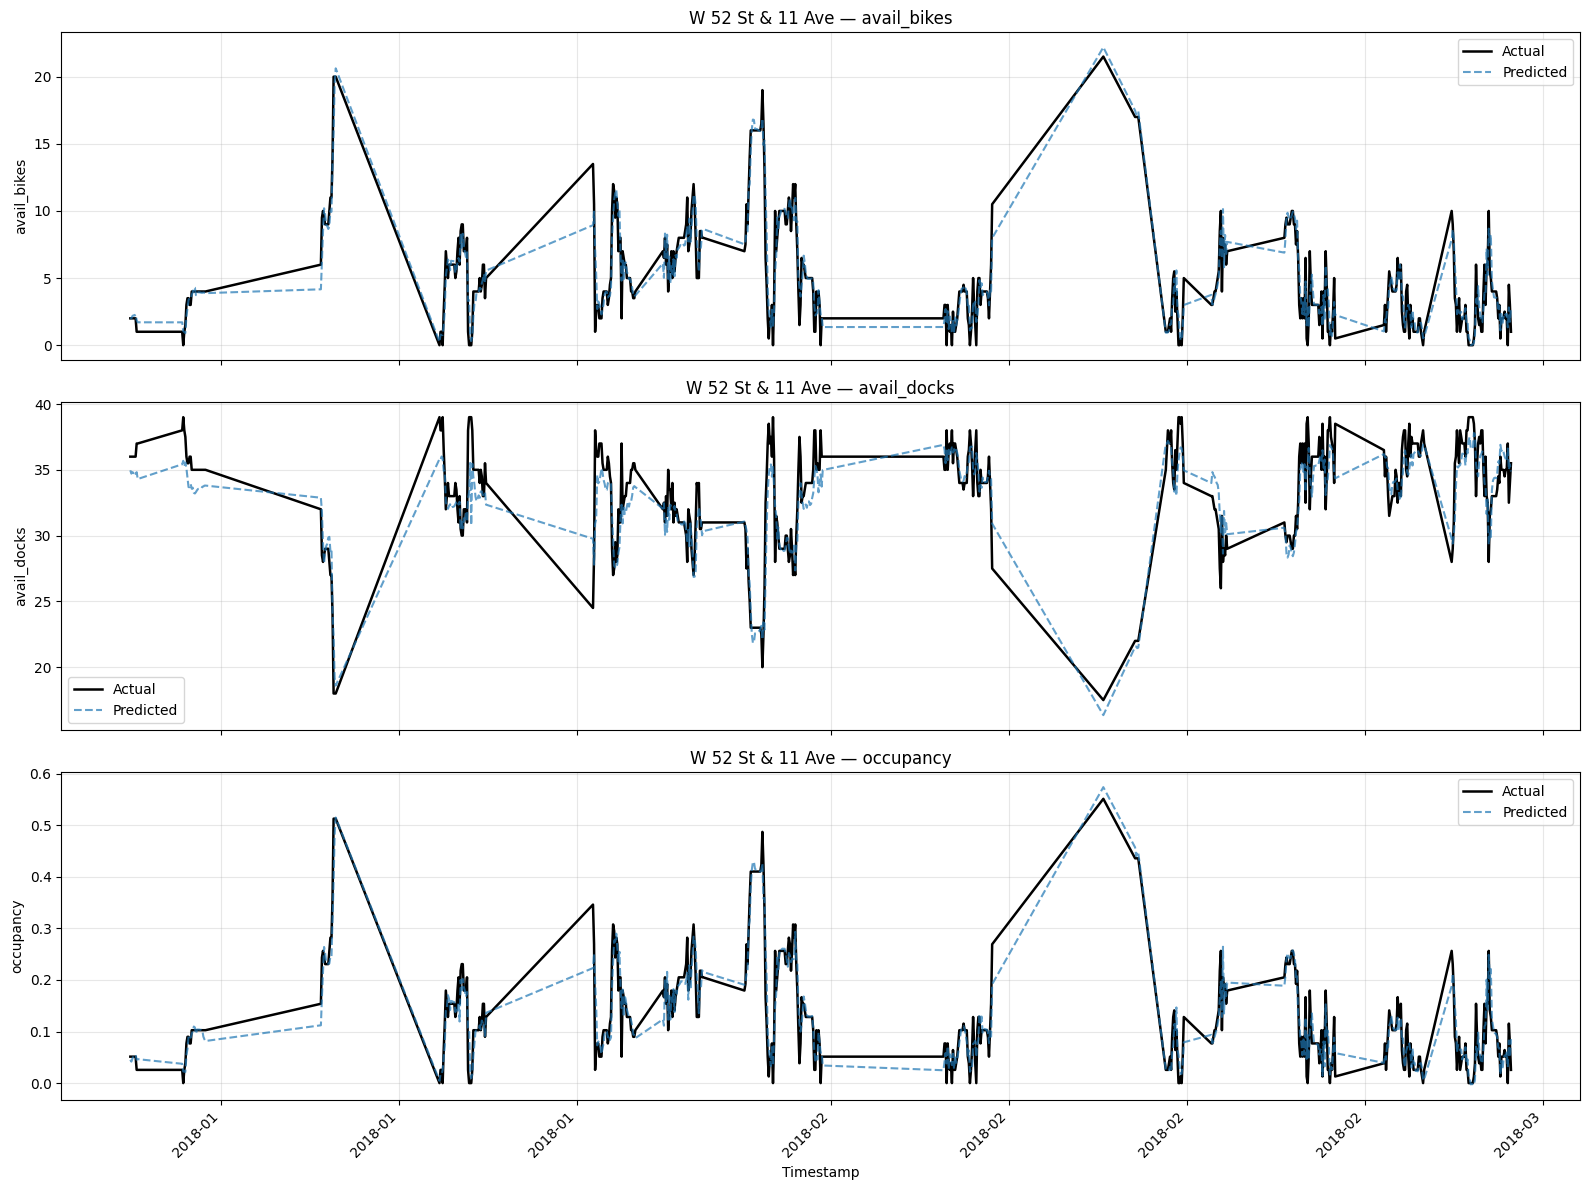

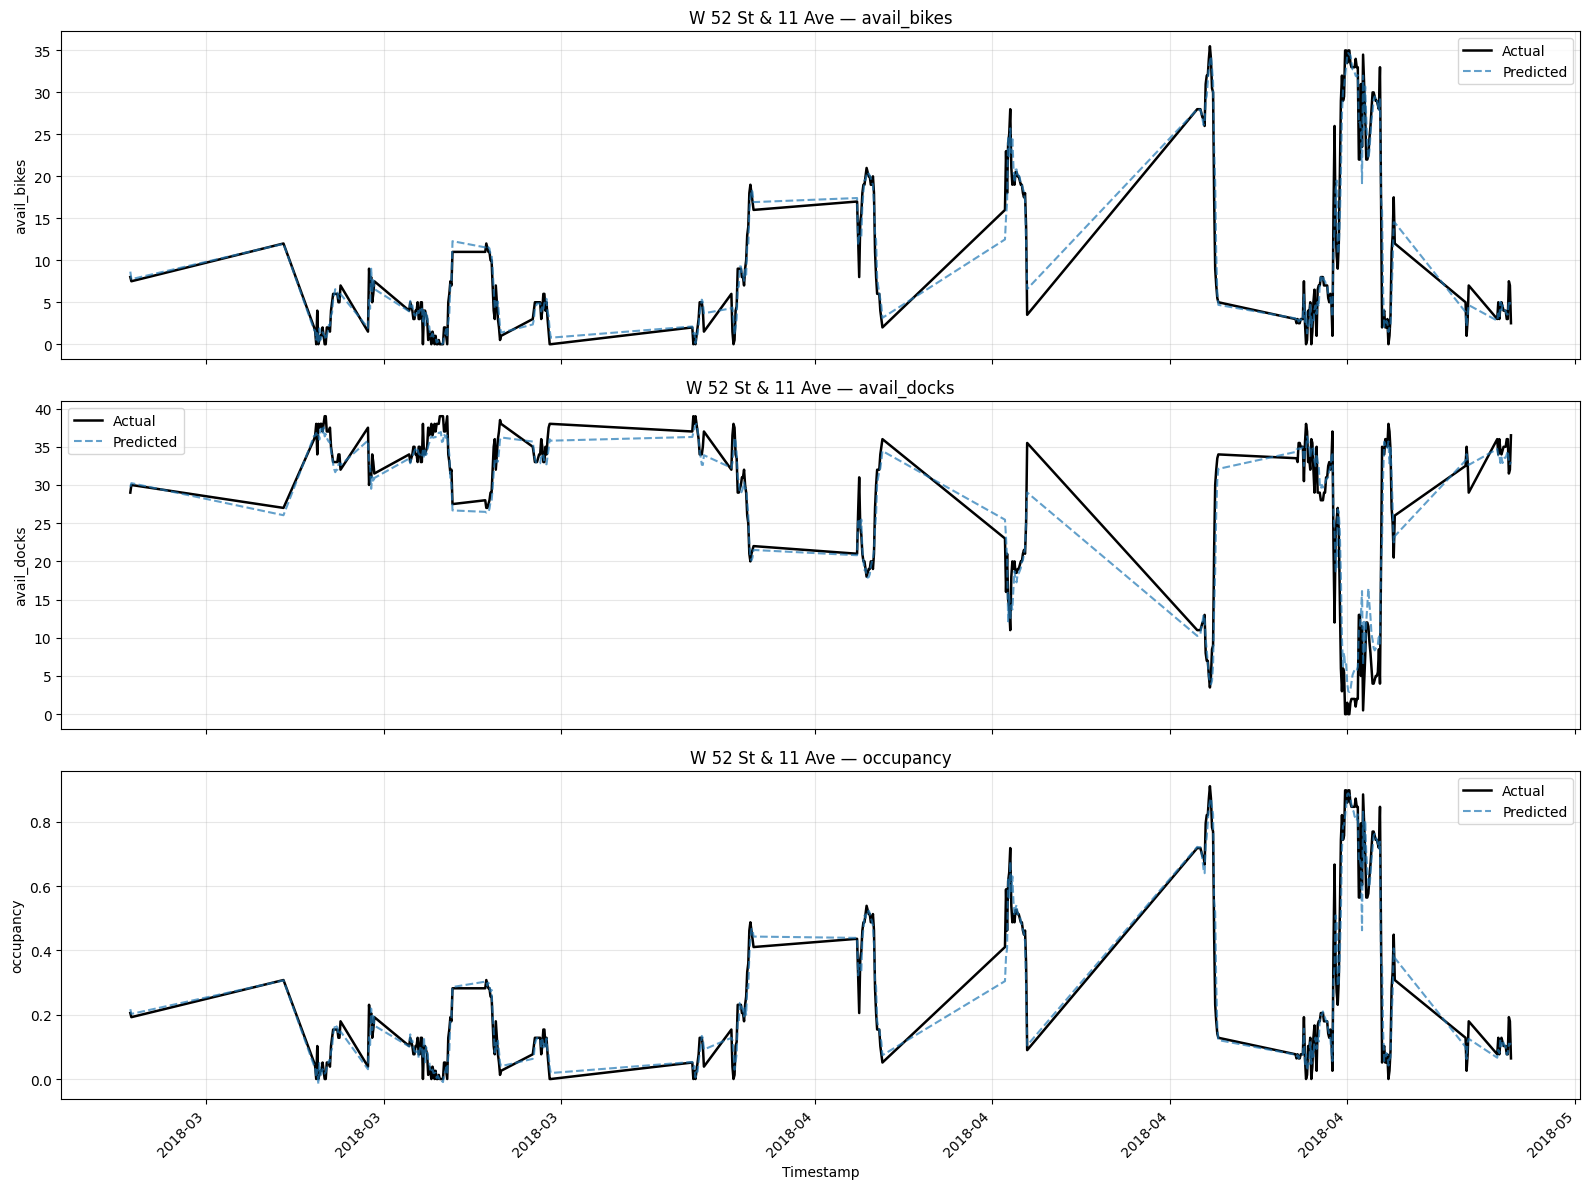

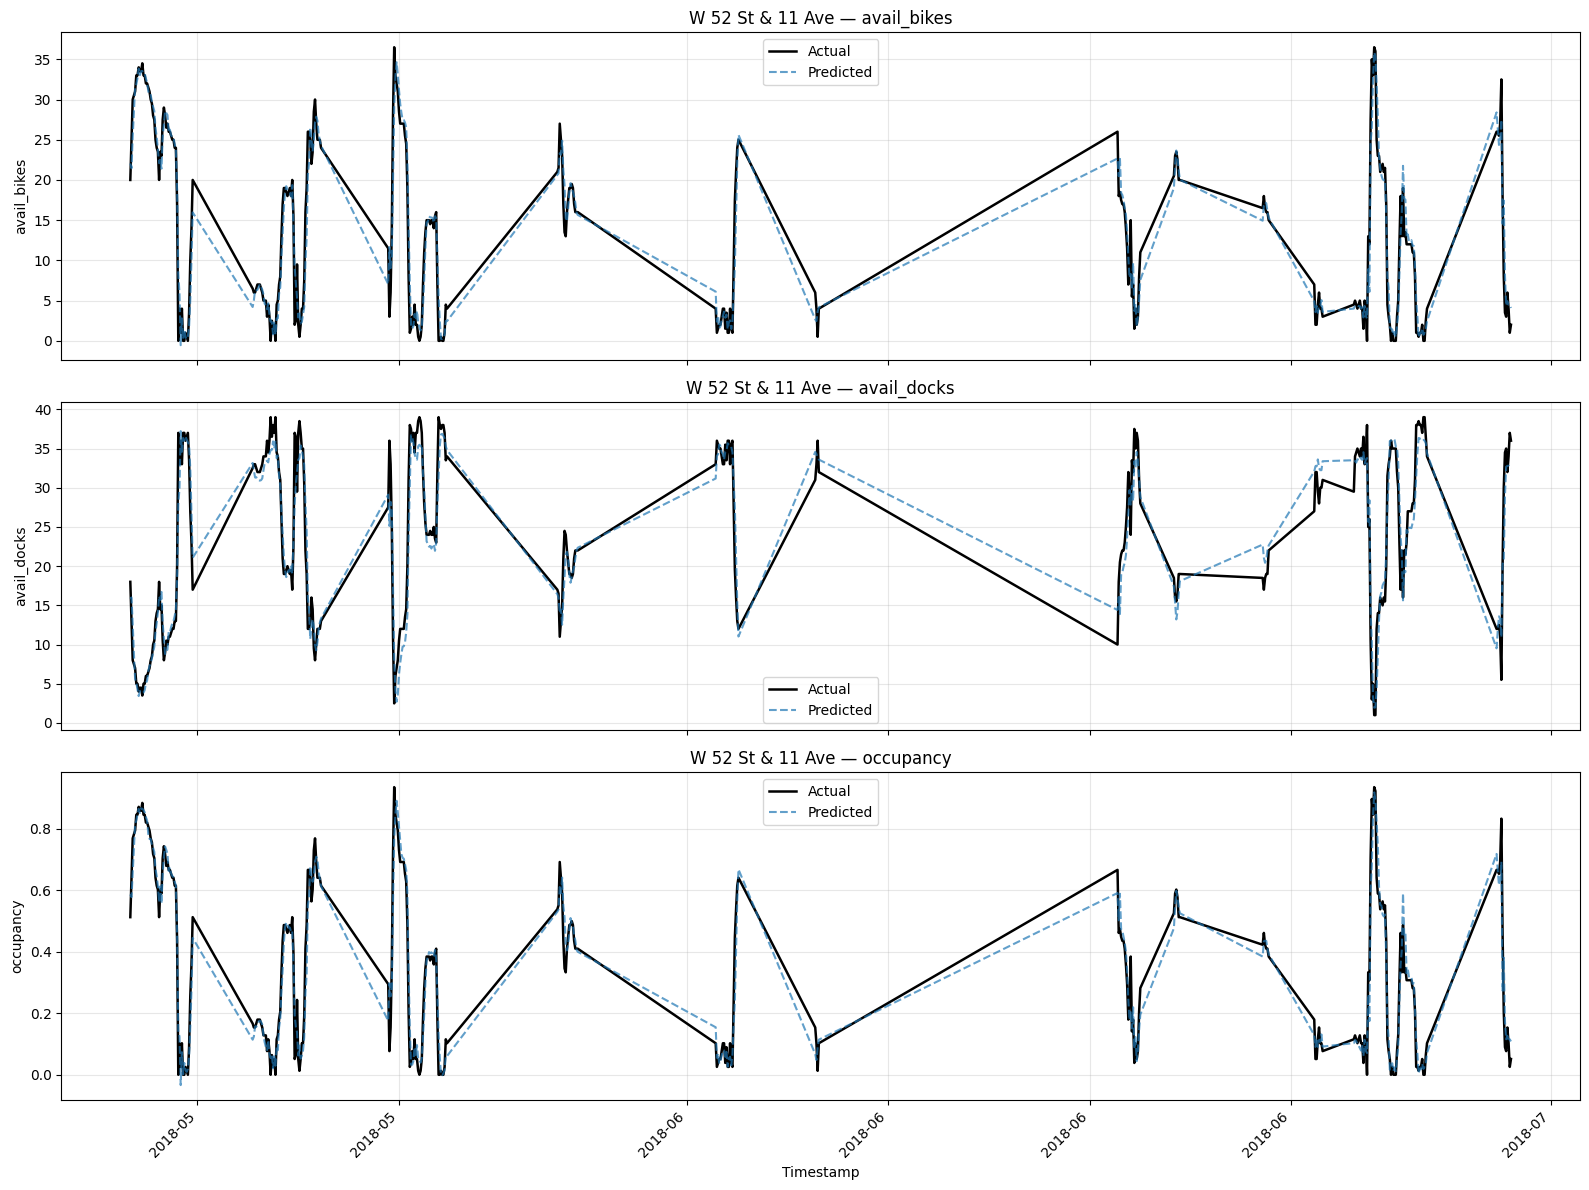

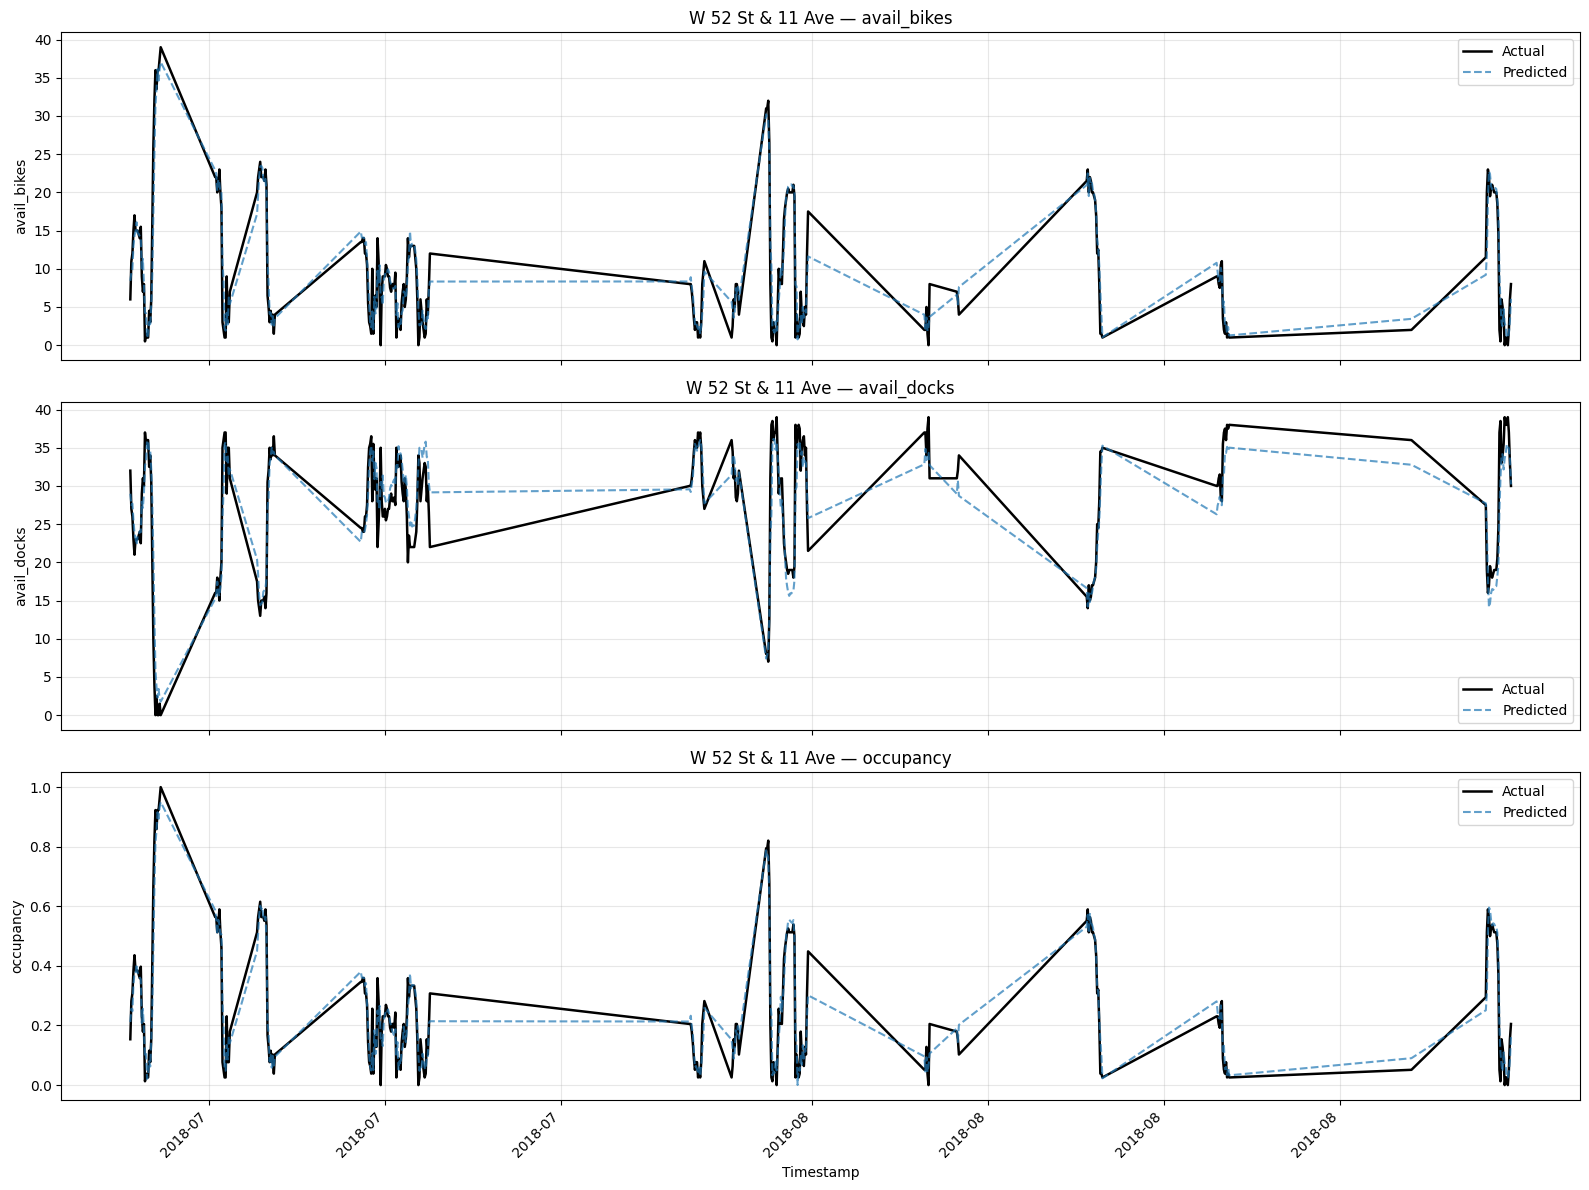

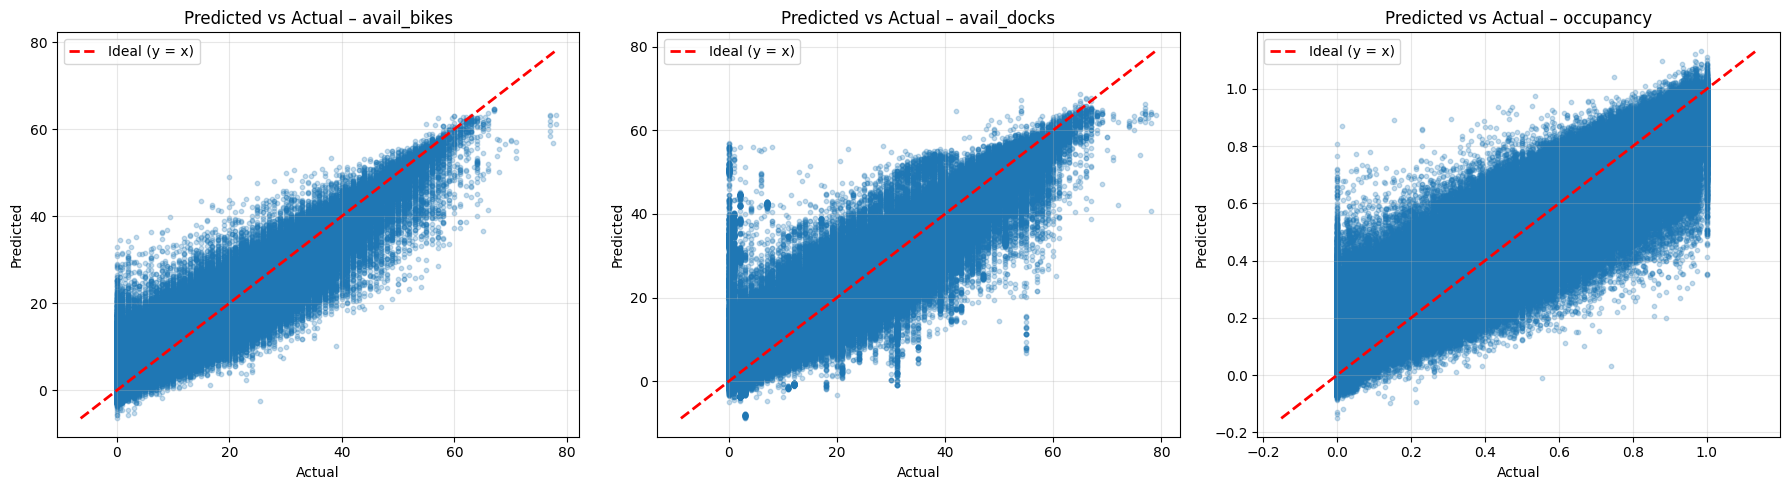

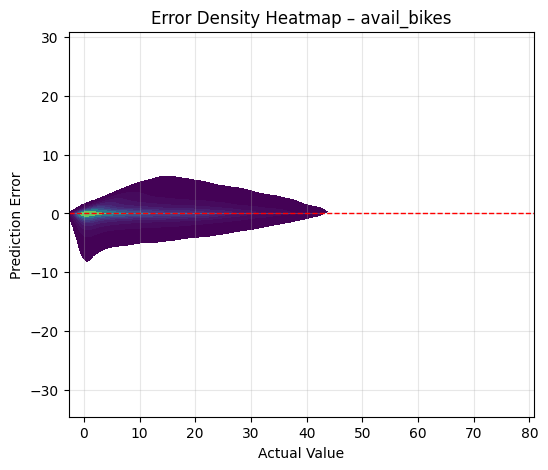

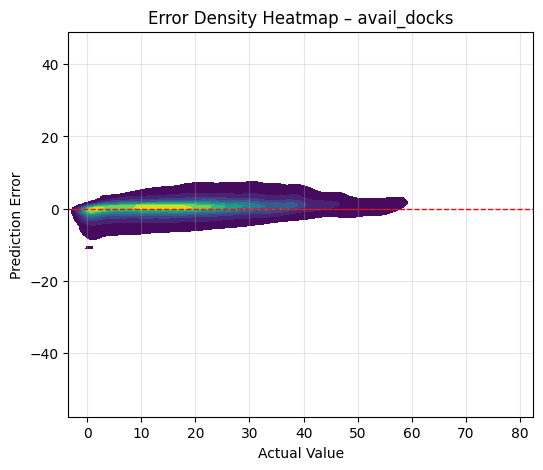

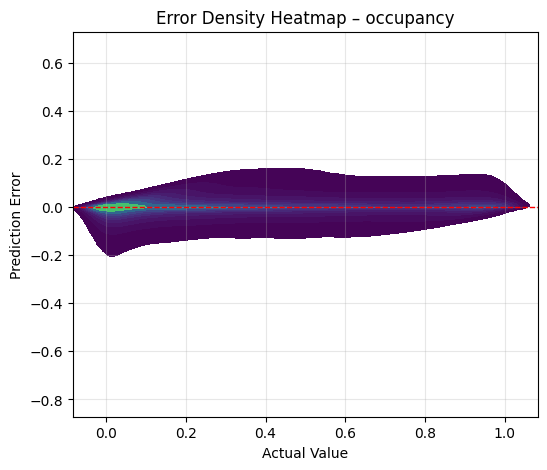

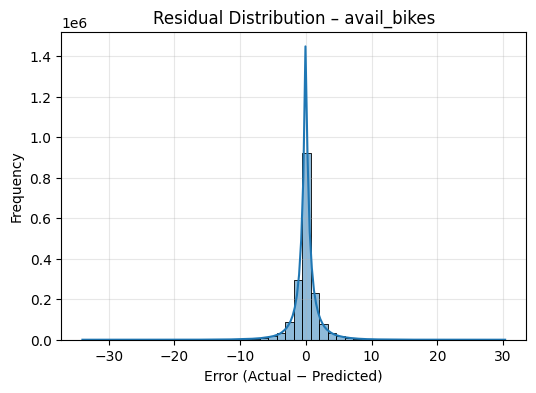

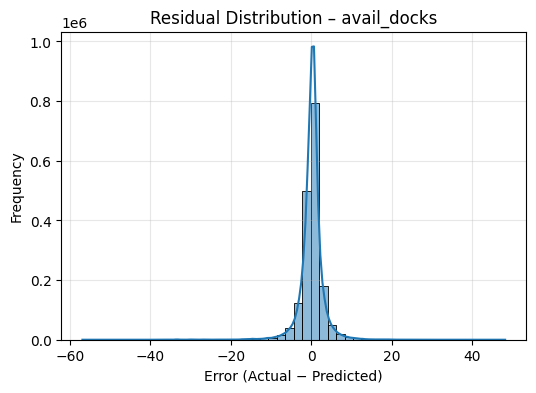

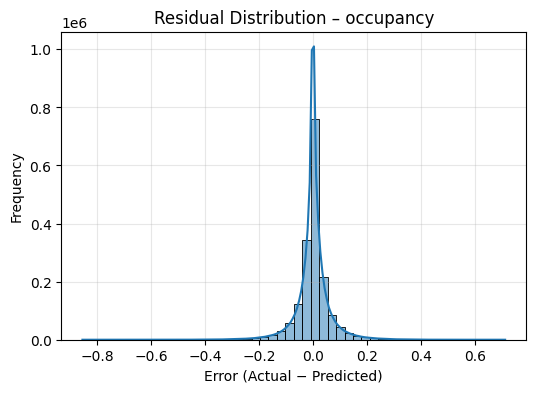

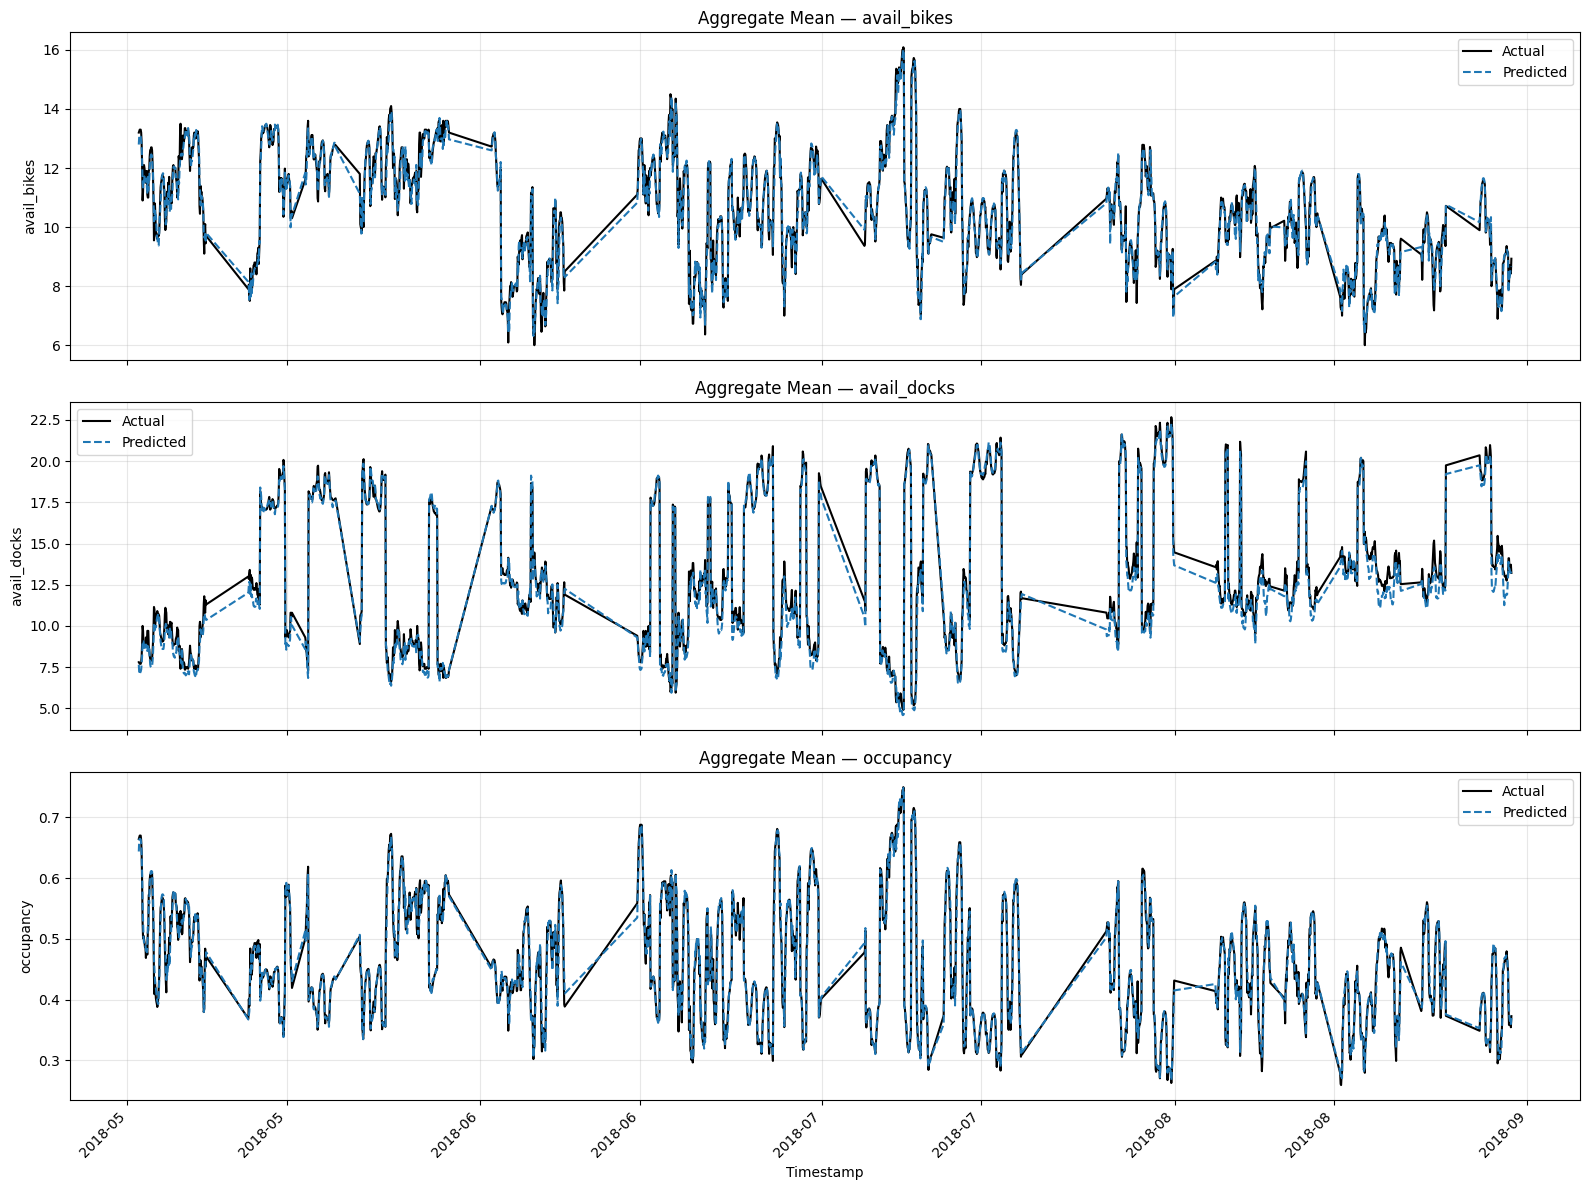


Top 5 Best Predictions (Occupancy):
               _lat      _long  tot_docks  hour  dayofweek  month  is_weekend  \
21042643  40.714402 -74.088772       14.0    12          5      2           1   
14590515  40.684568 -73.958811       19.0     7          4      1           0   
1110883   40.769918 -73.918406       31.0     2          4      1           0   
19250909  40.750380 -73.983390       39.0     3          3      5           0   
13927316  40.789485 -73.952429       35.0    12          6     12           1   

          is_holiday  lag_occ_1  lag_occ_24  roll_occ_3  roll_occ_24  \
21042643         0.0   0.285714    0.357143    0.285714     0.340774   
14590515         0.0   0.631579    0.421053    0.622807     0.576754   
1110883          0.0   0.000000    0.016129    0.000000     0.103495   
19250909         0.0   0.000000    0.000000    0.000000     0.000000   
13927316         0.0   0.200000    0.285714    0.209524     0.227976   

          temperature_2m  relative_humidity

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


✅ Model saved to xgboost_multioutput.pkl


xgb_avail_bikes_MAE,▁
xgb_avail_bikes_MAPE,▁
xgb_avail_bikes_R2,▁
xgb_avail_bikes_RMSE,▁
xgb_avail_docks_MAE,▁
xgb_avail_docks_MAPE,▁
xgb_avail_docks_R2,▁
xgb_avail_docks_RMSE,▁
xgb_occupancy_MAE,▁
xgb_occupancy_MAPE,▁
+2,...


🎉 XGBoost pipeline completed successfully


In [1]:
"""
============================================================
XGBoost Multi-Output Forecasting Pipeline
Project: NYC Citi Bike Congestion Intelligence
Course: CS559
============================================================

This script:
- Loads historical Citi Bike data
- Performs hourly resampling + feature engineering
- Trains a GLOBAL multi-output XGBoost model
- Predicts: avail_bikes, avail_docks, occupancy
- Evaluates using RMSE, MAE, R2, MAPE
- Generates diagnostic plots
- Logs rich artifacts to Weights & Biases
- Saves trained model for production use
"""

# ============================================================
# 0. IMPORTS
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import wandb
import xgboost as xgb

from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor


# ============================================================
# 1. WANDB SETUP
# ============================================================

WANDB_API_KEY = "8167d8f0f429b191c4958866ae4a9ef380ae62ef"

wandb.login(key=WANDB_API_KEY)

run = wandb.init(
    project="cs559",
    name=f"xgboost_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    config={
        "model": "XGBoost MultiOutput",
        "n_estimators": 400,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    }
)


# ============================================================
# 2. LOAD DATA
# ============================================================

DATA_DIR = "data"   # <-- change if needed

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
if not csv_files:
    raise FileNotFoundError("❌ No CSV files found in data directory")

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)


# CLEAN STATION NAMES (REMOVE EXTRA QUOTES & NORMALIZE)

df["dock_name"] = (
    df["dock_name"]
    .astype(str)
    .str.strip()                 # remove leading/trailing spaces
    .str.strip('"')              # remove starting/ending double quotes
    .str.strip("'")              # remove starting/ending single quotes
)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["dock_name", "timestamp"])

print(f"✅ Loaded {len(df)} rows from {len(csv_files)} files")


# ============================================================
# 3. FEATURE ENGINEERING (GLOBAL, HOURLY)
# ============================================================

def build_global_hourly(df: pd.DataFrame) -> pd.DataFrame:
    hourly = (
        df
        .set_index("timestamp")
        .groupby("dock_name")
        .resample("1H")
        .mean()
        .reset_index()
    )

    # Time features
    hourly["hour"] = hourly["timestamp"].dt.hour
    hourly["dayofweek"] = hourly["timestamp"].dt.dayofweek
    hourly["month"] = hourly["timestamp"].dt.month
    hourly["is_weekend"] = hourly["dayofweek"].isin([5, 6]).astype(int)

    # Lag features
    hourly["lag_occ_1"] = hourly.groupby("dock_name")["occupancy"].shift(1)
    hourly["lag_occ_24"] = hourly.groupby("dock_name")["occupancy"].shift(24)

    # Rolling features
    hourly["roll_occ_3"] = (
        hourly.groupby("dock_name")["occupancy"]
        .rolling(3).mean()
        .reset_index(0, drop=True)
    )

    hourly["roll_occ_24"] = (
        hourly.groupby("dock_name")["occupancy"]
        .rolling(24).mean()
        .reset_index(0, drop=True)
    )

    return hourly.dropna()


hourly_df = build_global_hourly(df)
print(f"✅ Hourly dataset size: {len(hourly_df)} rows")


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

SPLIT_DATE = "2017-05-01"

train_df = hourly_df[hourly_df["timestamp"] < SPLIT_DATE]
test_df  = hourly_df[hourly_df["timestamp"] >= SPLIT_DATE]

FEATURES = [
    "_lat", "_long", "tot_docks",
    "hour", "dayofweek", "month", "is_weekend", "is_holiday",
    "lag_occ_1", "lag_occ_24", "roll_occ_3", "roll_occ_24",
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m"
]

TARGETS = ["avail_bikes", "avail_docks", "occupancy"]

X_train = train_df[FEATURES]
y_train = train_df[TARGETS]

X_test = test_df[FEATURES]
y_test = test_df[TARGETS]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

print("\n📅 TRAIN DATE RANGE")
print("Start:", train_df["timestamp"].min())
print("End  :", train_df["timestamp"].max())

print("\n📅 TEST DATE RANGE")
print("Start:", test_df["timestamp"].min())
print("End  :", test_df["timestamp"].max())


# ============================================================
# 5. METRICS
# ============================================================

def safe_mape(y_true, y_pred):
    mask = np.abs(y_true) > 1e-6
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def compute_metrics(y_true, y_pred, prefix):
    metrics = {}
    for i, col in enumerate(TARGETS):
        metrics[f"{prefix}_{col}_RMSE"] = np.sqrt(
            mean_squared_error(y_true.iloc[:, i], y_pred[:, i])
        )
        metrics[f"{prefix}_{col}_MAE"] = mean_absolute_error(
            y_true.iloc[:, i], y_pred[:, i]
        )
        metrics[f"{prefix}_{col}_R2"] = r2_score(
            y_true.iloc[:, i], y_pred[:, i]
        )
        metrics[f"{prefix}_{col}_MAPE"] = safe_mape(
            y_true.iloc[:, i], y_pred[:, i]
        )
    return metrics


# ============================================================
# 6. TRAIN XGBOOST (MULTI-OUTPUT)
# ============================================================

xgb_base = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

model = MultiOutputRegressor(xgb_base)
model.fit(X_train, y_train)

xgb_preds = model.predict(X_test)

print("✅ XGBoost training complete")


# ============================================================
# 7. EVALUATION + WANDB LOGGING
# ============================================================

metrics = compute_metrics(y_test, xgb_preds, "xgb")
wandb.log(metrics)

print("\nEvaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


# ============================================================
# 8. VISUALIZATIONS (ENHANCED & REPORT-READY)
# ============================================================

import matplotlib.dates as mdates

def plot_actual_vs_pred_time_station(
    test_df,
    y_true,
    y_pred,
    dock_name="W 52 St & 11 Ave",
    start=None,
    end=None
):
    """
    Station-level Actual vs Predicted time series plot

    Parameters
    ----------
    test_df : pd.DataFrame (must include 'timestamp' and 'dock_name')
    y_true  : pd.DataFrame (targets)
    y_pred  : np.ndarray  (predictions aligned with y_true)
    dock_name : str       (station to plot)
    start, end : str or None (YYYY-MM-DD)
    """

    # -------- Filter by station --------
    station_mask = test_df["dock_name"] == dock_name
    if station_mask.sum() == 0:
        raise ValueError(f"No data found for station: {dock_name}")

    timestamps = pd.to_datetime(test_df.loc[station_mask, "timestamp"])
    y_true_s   = y_true.loc[station_mask]
    y_pred_s  = y_pred[station_mask.values]

    # -------- Time window handling --------
    if start:
        start = pd.to_datetime(start)
    if end:
        end = pd.to_datetime(end)

    if start and end and start > end:
        raise ValueError("start date must be <= end date")

    if start or end:
        time_mask = (
            (timestamps >= start if start else True) &
            (timestamps <= end if end else True)
        )

        timestamps = timestamps[time_mask]
        y_true_s   = y_true_s.loc[time_mask]
        y_pred_s  = y_pred_s[time_mask.values]

    # -------- Plot --------
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    for i, col in enumerate(TARGETS):
        axes[i].plot(
            timestamps,
            y_true_s[col].values,
            label="Actual",
            color="black",
            linewidth=1.8
        )
        axes[i].plot(
            timestamps,
            y_pred_s[:, i],
            label="Predicted",
            linestyle="--",
            alpha=0.7
        )

        axes[i].set_title(f"{dock_name} — {col}")
        axes[i].set_ylabel(col)
        axes[i].grid(alpha=0.3)
        axes[i].legend()

    axes[-1].set_xlabel("Timestamp")
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()

    # -------- Log to W&B --------
    wandb.log({
        f"station_{dock_name}_actual_vs_pred_{start.date() if start else 'full'}_{end.date() if end else 'full'}":
        wandb.Image(fig)
    })

    plt.show()


# Scatter Plot

def plot_pred_vs_actual_scatter(y_true, y_pred):
    """
    Scatter plot with y=x reference line
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, col in enumerate(TARGETS):
        axes[i].scatter(
            y_true[col],
            y_pred[:, i],
            alpha=0.25,
            s=10
        )

        min_val = min(y_true[col].min(), y_pred[:, i].min())
        max_val = max(y_true[col].max(), y_pred[:, i].max())

        axes[i].plot(
            [min_val, max_val],
            [min_val, max_val],
            "r--",
            linewidth=2,
            label="Ideal (y = x)"
        )

        axes[i].set_title(f"Predicted vs Actual – {col}")
        axes[i].set_xlabel("Actual")
        axes[i].set_ylabel("Predicted")
        axes[i].legend()
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    wandb.log({
    "actual_vs_pred_scatter_plot": wandb.Image(plt.gcf())
    })
    plt.show()


# Residual Heatmap
def plot_error_heatmap(y_true, y_pred, bins=30):
    """
    2D density heatmap of Actual vs Error
    """
    for i, col in enumerate(TARGETS):
        residuals = y_true[col] - y_pred[:, i]

        heat_df = pd.DataFrame({
            "Actual": y_true[col],
            "Error": residuals
        })

        plt.figure(figsize=(6, 5))
        sns.kdeplot(
            data=heat_df,
            x="Actual",
            y="Error",
            fill=True,
            cmap="viridis",
            thresh=0.05
        )

        plt.axhline(0, color="red", linestyle="--", linewidth=1)
        plt.title(f"Error Density Heatmap – {col}")
        plt.xlabel("Actual Value")
        plt.ylabel("Prediction Error")
        plt.grid(alpha=0.3)
        wandb.log({
            "actual_vs_pred_heatmap": wandb.Image(plt.gcf())
        })
        plt.show()

def plot_residual_distribution(y_true, y_pred):
    for i, col in enumerate(TARGETS):
        residuals = y_true[col] - y_pred[:, i]

        plt.figure(figsize=(6, 4))
        sns.histplot(residuals, bins=50, kde=True)
        plt.title(f"Residual Distribution – {col}")
        plt.xlabel("Error (Actual − Predicted)")
        plt.ylabel("Frequency")
        plt.grid(alpha=0.3)
        wandb.log({
            "actual_vs_pred_distribution_plot": wandb.Image(plt.gcf())
        })
        # Log to W&B
        wandb.log({f"xgb_residuals_{col}": wandb.Histogram(residuals)})
        plt.show()
station_name = "W 52 St & 11 Ave"#"Journal Square"
plot_actual_vs_pred_time_station(
    test_df=test_df,# timestamps=test_df["timestamp"].values,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start="2017-05-01", #"2018-03-01",
    end= "2017-06-30"#"2018-04-30"
)

plot_actual_vs_pred_time_station(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start= "2017-07-01", #"2018-05-01",
    end= "2017-08-31"#"2018-06-30"
)

plot_actual_vs_pred_time_station(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start= "2017-09-01",#"2018-07-01",
    end= "2017-10-31" #"2018-08-31"
)

plot_actual_vs_pred_time_station(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start= "2017-11-01", #"2019-09-01",
    end= "2017-12-31"#"2019-10-31"
)

plot_actual_vs_pred_time_station(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start= "2018-01-01", #"2019-09-01",
    end= "2018-02-28"#"2019-10-31"
)

plot_actual_vs_pred_time_station(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start= "2018-03-01", #"2019-09-01",
    end= "2018-04-30"#"2019-10-31"
)

plot_actual_vs_pred_time_station(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start= "2018-05-01", #"2019-09-01",
    end= "2018-06-30"#"2019-10-31"
)

plot_actual_vs_pred_time_station(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    dock_name=station_name,
    start= "2018-07-01", #"2019-09-01",
    end= "2018-08-31"#"2019-10-31"
)

plot_pred_vs_actual_scatter(y_test, xgb_preds)


plot_error_heatmap(y_test, xgb_preds)

plot_residual_distribution(y_test, xgb_preds)

### aggregate plotting

def plot_actual_vs_pred_time_agg(
    test_df,
    y_true,
    y_pred,
    start=None,
    end=None
):
    """
    Aggregate (mean across stations) Actual vs Predicted plot
    """

    # Build aggregate dataframe
    agg_df = test_df.copy()
    agg_df["pred_avail_bikes"] = y_pred[:, 0]
    agg_df["pred_avail_docks"] = y_pred[:, 1]
    agg_df["pred_occupancy"]   = y_pred[:, 2]

    # Time window
    if start:
        start = pd.to_datetime(start)
    if end:
        end = pd.to_datetime(end)

    if start and end and start > end:
        raise ValueError("start date must be <= end date")

    if start or end:
        agg_df = agg_df[
            (agg_df["timestamp"] >= start if start else True) &
            (agg_df["timestamp"] <= end if end else True)
        ]

    # Aggregate by timestamp
    grouped = (
        agg_df
        .groupby("timestamp")[
            ["avail_bikes", "pred_avail_bikes",
             "avail_docks", "pred_avail_docks",
             "occupancy", "pred_occupancy"]
        ]
        .mean()
        .reset_index()
    )

    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    pairs = [
        ("avail_bikes", "pred_avail_bikes"),
        ("avail_docks", "pred_avail_docks"),
        ("occupancy", "pred_occupancy")
    ]

    for ax, (actual, pred) in zip(axes, pairs):
        ax.plot(grouped["timestamp"], grouped[actual], label="Actual", color="black")
        ax.plot(grouped["timestamp"], grouped[pred], label="Predicted", linestyle="--")
        ax.set_title(f"Aggregate Mean — {actual}")
        ax.set_ylabel(actual)
        ax.grid(alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("Timestamp")
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()

    # Log to W&B
    wandb.log({
        f"aggregate_actual_vs_pred_{start.date() if start else 'full'}_{end.date() if end else 'full'}":
        wandb.Image(fig)
    })

    plt.show()

plot_actual_vs_pred_time_agg(
    test_df=test_df,
    y_true=y_test,
    y_pred=xgb_preds,
    start="2018-05-01",
    end="2018-08-31"
)


# ============================================================
# 9. TOP-20 BEST & WORST PREDICTIONS (OCCUPANCY)
# ============================================================

def top_worst(X, y_true, y_pred, target_idx, n=20):
    df = X.copy()
    df["actual"] = y_true.iloc[:, target_idx].values
    df["pred"] = y_pred[:, target_idx]
    df["error"] = np.abs(df["actual"] - df["pred"])
    return df.sort_values("error").head(n), df.sort_values("error", ascending=False).head(n)


top20, worst20 = top_worst(X_test, y_test, xgb_preds, target_idx=2)

print("\nTop 5 Best Predictions (Occupancy):")
print(top20.head())

print("\nTop 5 Worst Predictions (Occupancy):")
print(worst20.head())


# ============================================================
# 10. WANDB TABLE (PREDICTIONS SAMPLE)
# ============================================================

table = wandb.Table(columns=[
    "avail_bikes_actual", "avail_bikes_pred",
    "avail_docks_actual", "avail_docks_pred",
    "occupancy_actual", "occupancy_pred"
])

for i in range(min(2000, len(y_test))):
    table.add_data(
        y_test.iloc[i, 0], xgb_preds[i, 0],
        y_test.iloc[i, 1], xgb_preds[i, 1],
        y_test.iloc[i, 2], xgb_preds[i, 2]
    )

wandb.log({"xgb_predictions_sample": table})


# ============================================================
# 11. SAVE MODEL
# ============================================================

MODEL_PATH = "xgboost_multioutput.pkl"
joblib.dump(model, MODEL_PATH)
wandb.save(MODEL_PATH)

print(f"✅ Model saved to {MODEL_PATH}")


# ============================================================
# 12. FINISH
# ============================================================

wandb.finish()
print("🎉 XGBoost pipeline completed successfully")


In [23]:
(test_df["dock_name"] == station_name).any()

False

In [25]:
test_df["dock_name"].unique()

array(['1 Ave & E 110 St', '1 Ave & E 16 St', '1 Ave & E 18 St',
       '1 Ave & E 30 St', '1 Ave & E 44 St', '1 Ave & E 62 St',
       '1 Ave & E 68 St', '1 Ave & E 78 St', '1 Ave & E 94 St',
       '1 Pl & Clinton St', '10 St & 5 Ave', '10 St & 7 Ave',
       '11 Ave & W 27 St', '11 Ave & W 41 St', '11 Ave & W 59 St',
       '12 Ave & W 40 St', '12 St & 4 Ave', '14 St & 5 Ave',
       '14 St & 7 Ave', '19 St & 24 Ave',
       '2 Ave & 36 St - Citi Bike HQ at Industry City', '2 Ave & 9 St',
       '2 Ave & E 104 St', '2 Ave & E 122 St', '2 Ave & E 31 St',
       '2 Ave & E 96 St', '2 Ave & E 99 St', '21 St & 43 Ave',
       '21 St & Hoyt Ave S', '21 St & Queens Plaza North',
       '23 Ave & 27 St', '24 Ave & 26 St', '24 Ave & 29 St',
       '27 Ave & 4 St', '3 Ave & 14 St', '3 Ave & E 100 St',
       '3 Ave & E 62 St', '3 Ave & E 71 St', '3 Ave & E 72 St',
       '3 Ave & Schermerhorn St', '3 St & 3 Ave', '3 St & 7 Ave',
       '3 St & Hoyt St', '3 St & Prospect Park West', '31 St & 

## ARIMA Model

In [ ]:
"""
============================================================
ARIMA & ARIMAX Forecasting Pipeline
Project: NYC Citi Bike Congestion Intelligence
Course: CS559
Author: Komal Wavhal
============================================================

This script:
- Loads historical Citi Bike data
- Performs hourly resampling + feature engineering
- Trains GLOBAL ARIMA (univariate) models
- Trains GLOBAL ARIMAX (exogenous variables)
- Targets: avail_bikes, avail_docks, occupancy
- Evaluates using RMSE, MAE, R2, MAPE
- Generates diagnostic plots
- Logs artifacts to Weights & Biases
- Saves fitted models
"""

# ============================================================
# 0. IMPORTS
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import wandb

from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.dates as mdates


# ============================================================
# 1. WANDB SETUP
# ============================================================

 

WANDB_API_KEY = "8167d8f0f429b191c4958866ae4a9ef380ae62ef"

wandb.login(key=WANDB_API_KEY)

 

run = wandb.init(
    project="cs559",
    name=f"arimax_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    config={
        "model": "ARIMA / ARIMAX",
        "order": (1, 0, 1),
        "seasonal_order": (1, 0, 1, 24)
    }
)
DATA_DIR = "data"

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
if not csv_files:
    raise FileNotFoundError("❌ No CSV files found")

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df["dock_name"] = (
    df["dock_name"]
    .astype(str)
    .str.strip()
    .str.strip('"')
    .str.strip("'")
)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["dock_name", "timestamp"])

print(f"✅ Loaded {len(df)} rows")
def build_global_hourly(df):
    hourly = (
        df
        .set_index("timestamp")
        .groupby("dock_name")
        .resample("1H")
        .mean()
        .reset_index()
    )

    hourly["hour"] = hourly["timestamp"].dt.hour
    hourly["dayofweek"] = hourly["timestamp"].dt.dayofweek
    hourly["month"] = hourly["timestamp"].dt.month
    hourly["is_weekend"] = hourly["dayofweek"].isin([5, 6]).astype(int)

    hourly["lag_occ_1"] = hourly.groupby("dock_name")["occupancy"].shift(1)
    hourly["lag_occ_24"] = hourly.groupby("dock_name")["occupancy"].shift(24)

    hourly["roll_occ_3"] = hourly.groupby("dock_name")["occupancy"].rolling(3).mean().reset_index(0, drop=True)
    hourly["roll_occ_24"] = hourly.groupby("dock_name")["occupancy"].rolling(24).mean().reset_index(0, drop=True)

    return hourly.dropna()


hourly_df = build_global_hourly(df)
print(f"✅ Hourly dataset size: {len(hourly_df)}")
SPLIT_DATE = "2017-05-01"

train_df = hourly_df[hourly_df["timestamp"] < SPLIT_DATE]
test_df  = hourly_df[hourly_df["timestamp"] >= SPLIT_DATE]

EXOG_FEATURES = [
    "_lat", "_long", "tot_docks",
    "hour", "dayofweek", "month", "is_weekend", "is_holiday",
    "lag_occ_1", "lag_occ_24", "roll_occ_3", "roll_occ_24",
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m"
]

TARGETS = ["avail_bikes", "avail_docks", "occupancy"]
def safe_mape(y_true, y_pred):
    mask = np.abs(y_true) > 1e-6
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def compute_metrics(y_true, y_pred, prefix):
    return {
        f"{prefix}_RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        f"{prefix}_MAE": mean_absolute_error(y_true, y_pred),
        f"{prefix}_R2": r2_score(y_true, y_pred),
        f"{prefix}_MAPE": safe_mape(y_true, y_pred),
    }
ORDER = (1, 0, 1)
SEASONAL = (1, 0, 1, 24)

preds = {}
metrics_all = {}

for target in TARGETS:
    print(f"\n🔹 Training ARIMA / ARIMAX for {target}")

    y_train = train_df[target]
    y_test  = test_df[target]

    X_train = train_df[EXOG_FEATURES]
    X_test  = test_df[EXOG_FEATURES]

    # ---------- ARIMA (no exog)
    arima = SARIMAX(
        y_train,
        order=ORDER,
        seasonal_order=SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    arima_pred = arima.get_forecast(len(y_test)).predicted_mean.values

    metrics_all[f"ARIMA_{target}"] = compute_metrics(
        y_test.values, arima_pred, f"ARIMA_{target}"
    )

    # ---------- ARIMAX
    arimax = SARIMAX(
        y_train,
        exog=X_train,
        order=ORDER,
        seasonal_order=SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    arimax_pred = arimax.get_forecast(
        steps=len(y_test),
        exog=X_test
    ).predicted_mean.values

    metrics_all[f"ARIMAX_{target}"] = compute_metrics(
        y_test.values, arimax_pred, f"ARIMAX_{target}"
    )

    preds[target] = {
        "ARIMA": arima_pred,
        "ARIMAX": arimax_pred
    }

    # Save models
    joblib.dump(arima, f"arima_{target}.pkl")
    joblib.dump(arimax, f"arimax_{target}.pkl")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/komalwavhal/.netrc
/Users/komalwavhal/Documents/Anaconda_Software/anaconda3/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


✅ Loaded 23180369 rows


/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_58894/2269398177.py:86: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")


✅ Hourly dataset size: 2392762

🔹 Training ARIMA / ARIMAX for avail_bikes


/Users/komalwavhal/Documents/Anaconda_Software/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/komalwavhal/Documents/Anaconda_Software/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


wandb: WARNING Failed to create global config settings in: /Users/komalwavhal/.config/wandb. Settings will not be persisted.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/komalwavhal/.netrc
wandb: Currently logged in as: mc77chand (mc77chand-stevens-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Users/komalwavhal/Documents/Anaconda_Software/anaconda3/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


📦 Found 1 CSV file(s). Loading...
✅ Loaded 23,180,369 rows from 1 readable file(s).
✅ Hourly per-station rows: 21,452,479
✅ Aggregated hourly rows (global time series): 36,522
Train rows: 19,008 | Test rows: 17,514

📅 TRAIN DATE RANGE: 2015-03-01 00:00:00 → 2017-04-30 23:00:00
📅 TEST  DATE RANGE: 2017-05-01 00:00:00 → 2019-04-30 17:00:00

🔹 Training ARIMA / ARIMAX for: avail_bikes


/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:328: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_train = train_df[target].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:329: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_test  = test_df[target].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:331: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train = train_df[EXOG_FEATURES].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:332: FutureWarning: DataFrame.f

✅ Saved models for avail_bikes to: models_arimax_agg/

🔹 Training ARIMA / ARIMAX for: avail_docks


/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:328: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_train = train_df[target].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:329: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_test  = test_df[target].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:331: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train = train_df[EXOG_FEATURES].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:332: FutureWarning: DataFrame.f

✅ Saved models for avail_docks to: models_arimax_agg/

🔹 Training ARIMA / ARIMAX for: occupancy


/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:328: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_train = train_df[target].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:329: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_test  = test_df[target].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:331: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train = train_df[EXOG_FEATURES].astype(float).fillna(method="ffill").fillna(0.0)
/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:332: FutureWarning: DataFrame.f

✅ Saved models for occupancy to: models_arimax_agg/

📊 Evaluation Metrics (Aggregate Baseline):
ARIMA_avail_bikes
  ARIMA_avail_bikes_RMSE: 2.6172
  ARIMA_avail_bikes_MAE: 2.1909
  ARIMA_avail_bikes_R2: 0.0120
  ARIMA_avail_bikes_MAPE: 25.5337
ARIMAX_avail_bikes
  ARIMAX_avail_bikes_RMSE: 2.5723
  ARIMAX_avail_bikes_MAE: 2.0786
  ARIMAX_avail_bikes_R2: 0.0457
  ARIMAX_avail_bikes_MAPE: 24.5753
ARIMA_avail_docks
  ARIMA_avail_docks_RMSE: 2.5183
  ARIMA_avail_docks_MAE: 1.9625
  ARIMA_avail_docks_R2: 0.0181
  ARIMA_avail_docks_MAPE: 11.8697
ARIMAX_avail_docks
  ARIMAX_avail_docks_RMSE: 2.6845
  ARIMAX_avail_docks_MAE: 2.1346
  ARIMAX_avail_docks_R2: -0.1158
  ARIMAX_avail_docks_MAPE: 12.2245
ARIMA_occupancy
  ARIMA_occupancy_RMSE: 0.0663
  ARIMA_occupancy_MAE: 0.0522
  ARIMA_occupancy_R2: 0.1014
  ARIMA_occupancy_MAPE: 15.9385
ARIMAX_occupancy
  ARIMAX_occupancy_RMSE: 0.0658
  ARIMAX_occupancy_MAE: 0.0515
  ARIMAX_occupancy_R2: 0.1147
  ARIMAX_occupancy_MAPE: 15.8893


/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:401: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_true = test_df[target].astype(float).fillna(method="ffill").fillna(0.0).values


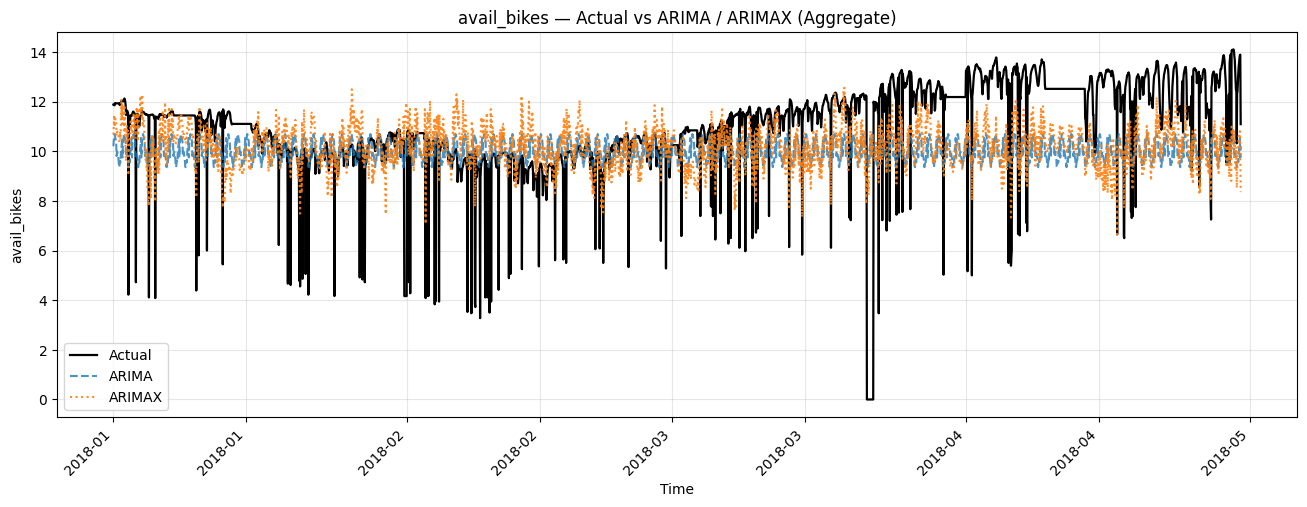

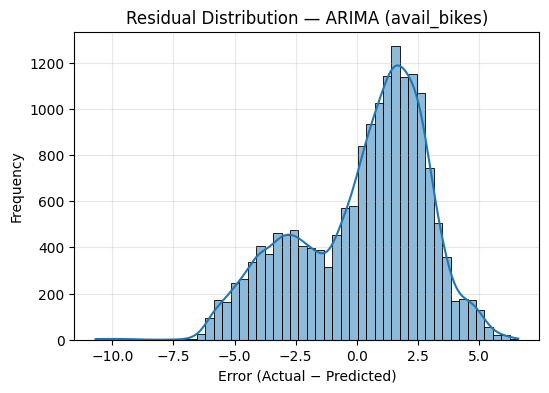

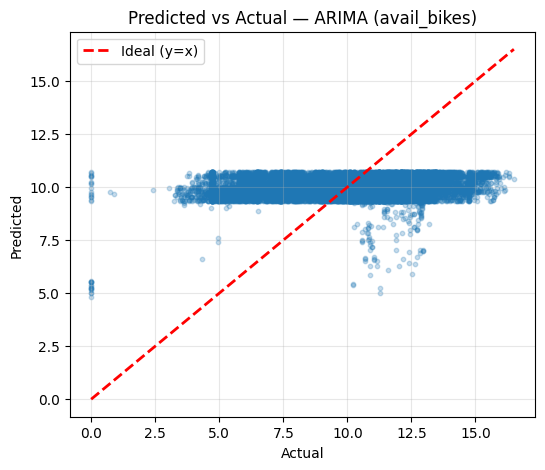

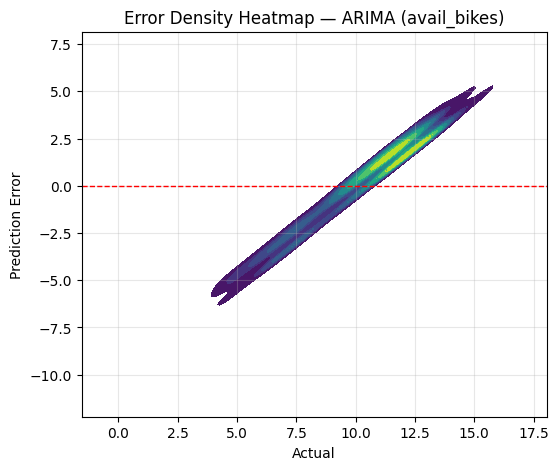

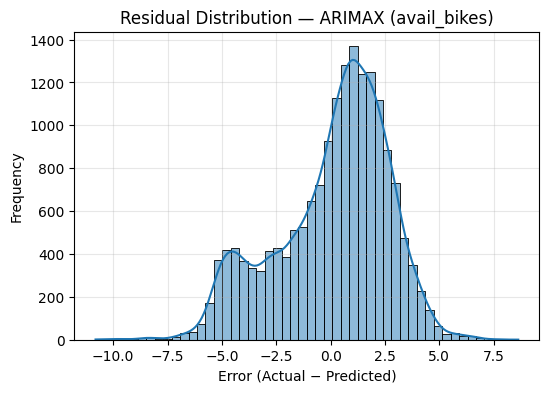

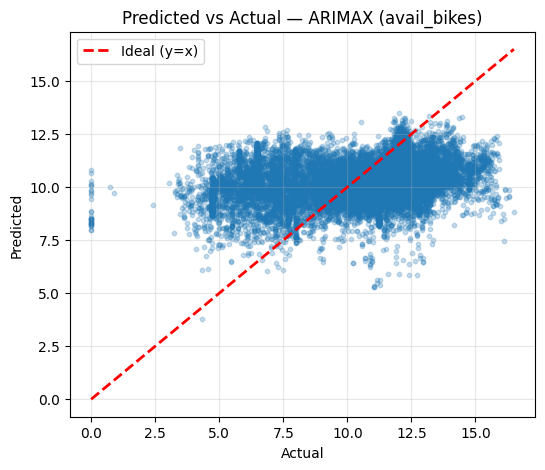

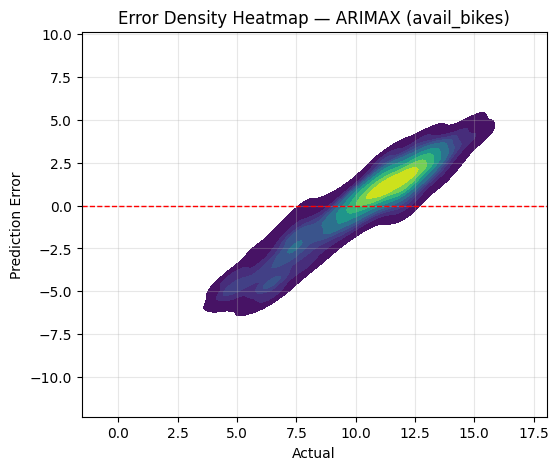

/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:401: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_true = test_df[target].astype(float).fillna(method="ffill").fillna(0.0).values


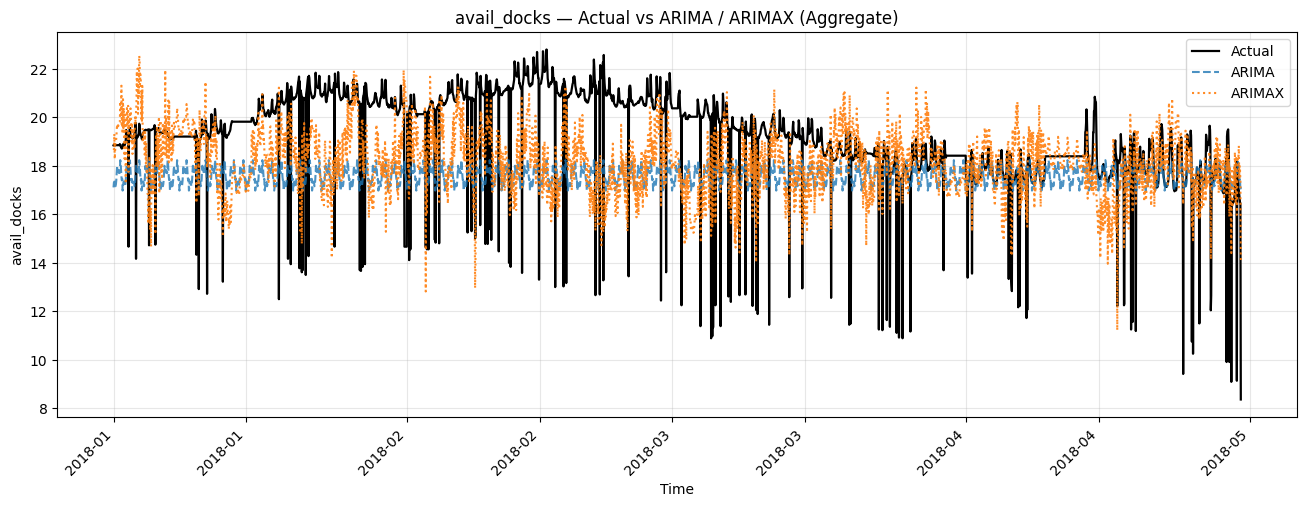

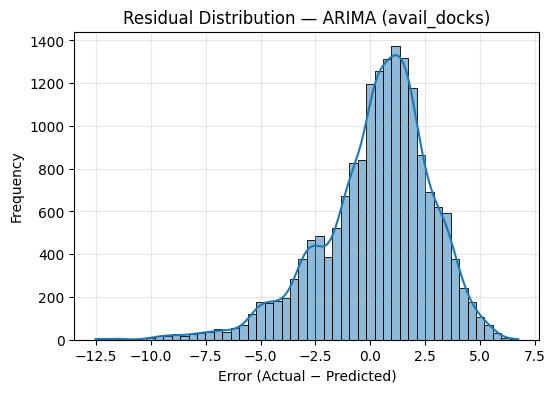

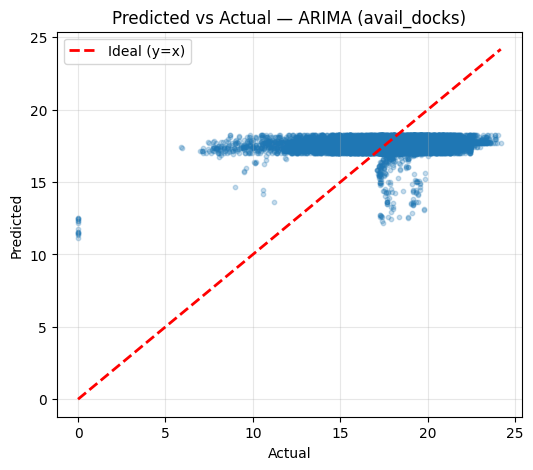

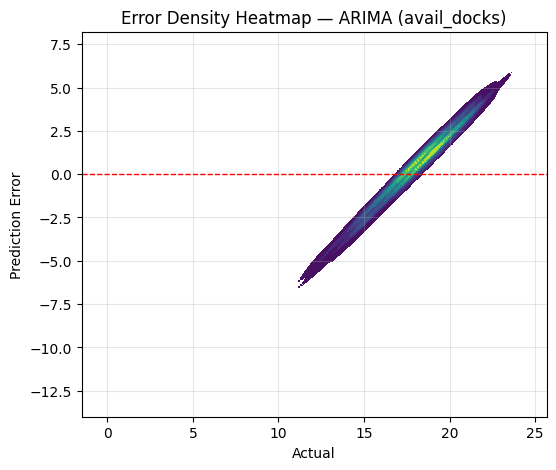

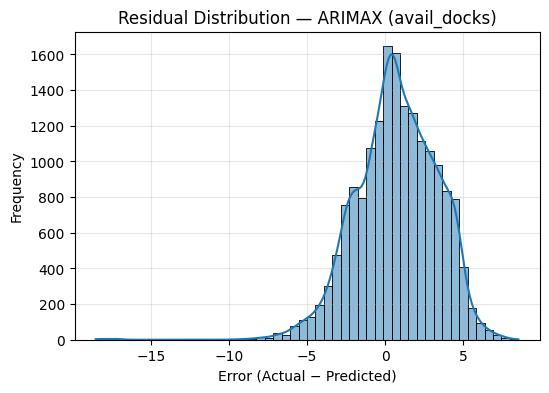

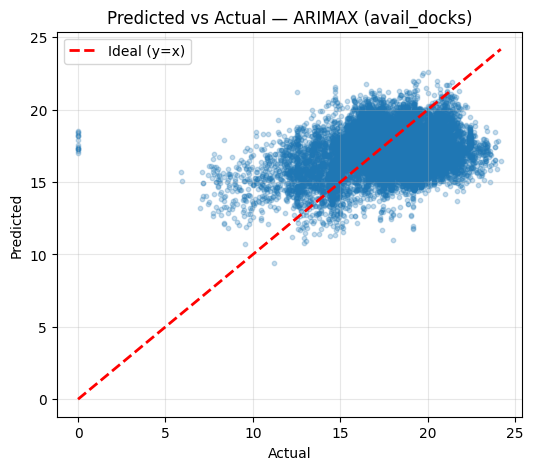

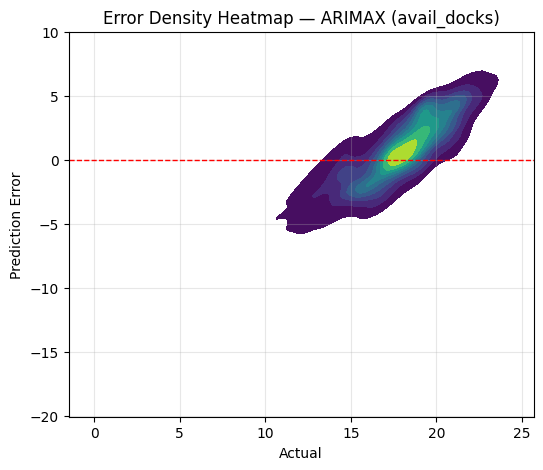

/var/folders/dk/7gsnjsy57mbg8gbd91pg003w0000gn/T/ipykernel_2197/2197317983.py:401: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_true = test_df[target].astype(float).fillna(method="ffill").fillna(0.0).values


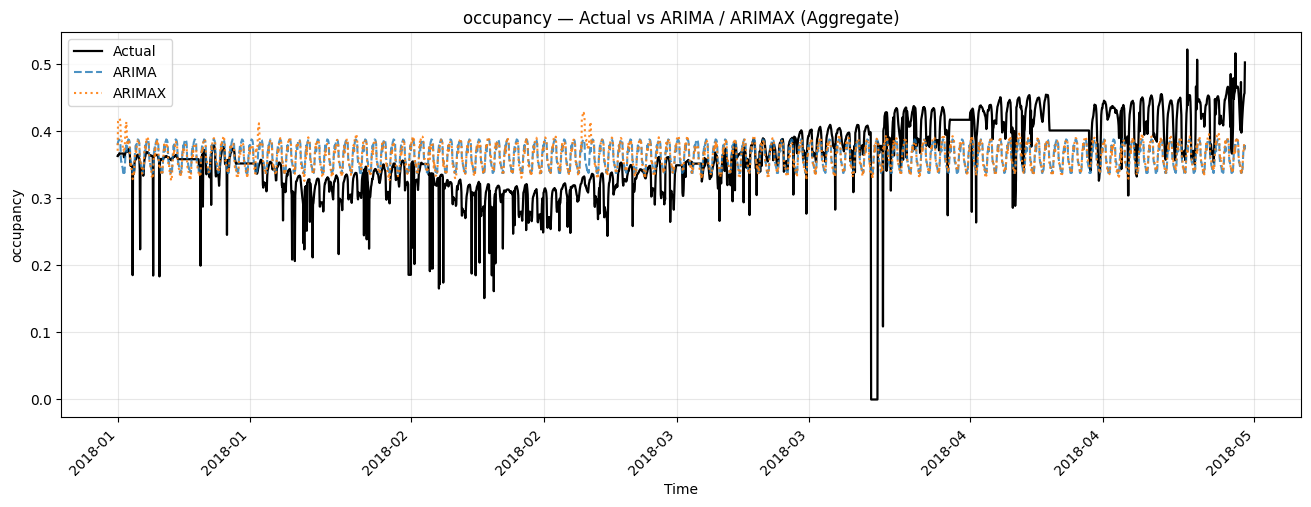

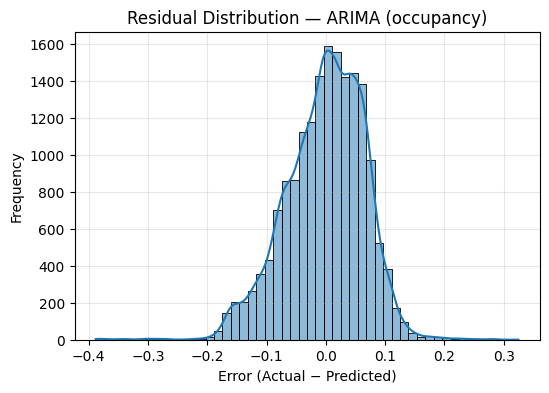

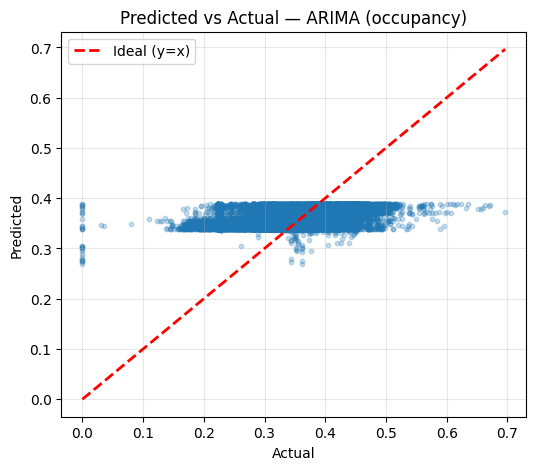

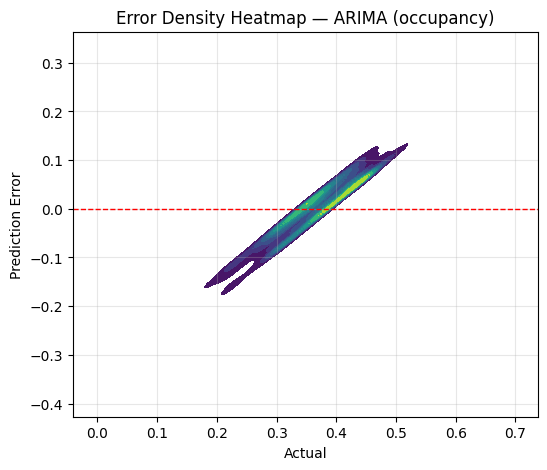

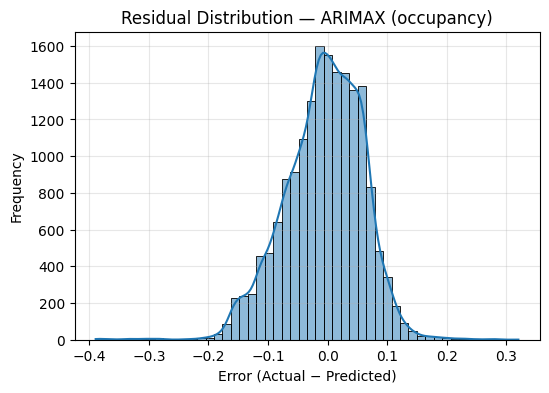

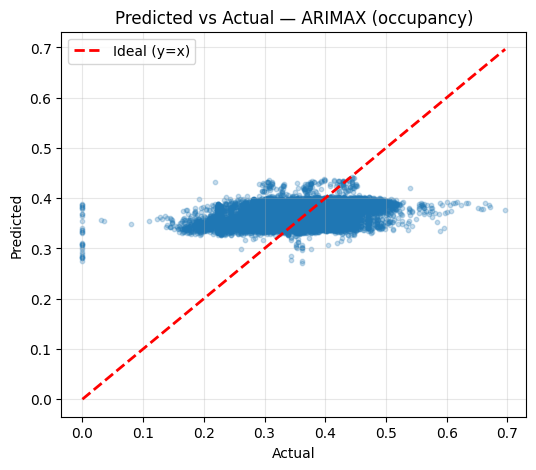

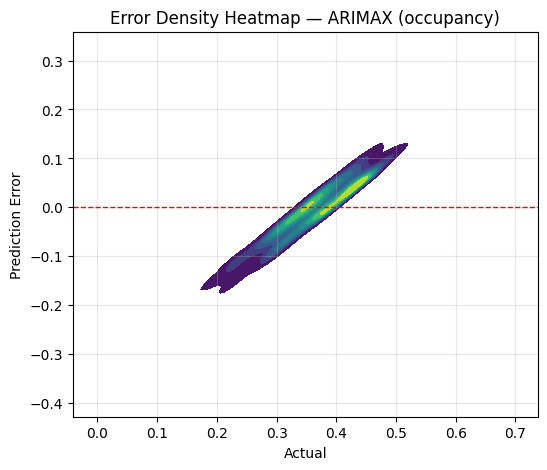

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


✅ Saved predictions to: models_arimax_agg/aggregate_arima_arimax_predictions.csv


ARIMAX_avail_bikes_MAE,▁
ARIMAX_avail_bikes_MAPE,▁
ARIMAX_avail_bikes_R2,▁
ARIMAX_avail_bikes_RMSE,▁
ARIMAX_avail_docks_MAE,▁
ARIMAX_avail_docks_MAPE,▁
ARIMAX_avail_docks_R2,▁
ARIMAX_avail_docks_RMSE,▁
ARIMAX_occupancy_MAE,▁
ARIMAX_occupancy_MAPE,▁
+14,...


🎉 ARIMA / ARIMAX (Aggregate Baseline) pipeline completed successfully!


In [1]:
"""
============================================================
FAST ARIMA & ARIMAX (AGGREGATE GLOBAL BASELINE) PIPELINE
Project: NYC Citi Bike Congestion Intelligence
Course: CS559
Author: Komal Wavhal
============================================================

Why this version is FAST:
- Trains ARIMA/ARIMAX on AGGREGATED (mean) hourly demand across stations
- Avoids fitting SARIMAX on millions of rows per station (computationally infeasible)
- Uses lightweight exogenous features (time + weather only)
- Still produces strong classical baselines for comparison with XGBoost

This script:
- Loads historical Citi Bike data (processed CSVs)
- Cleans station names + timestamps
- Builds hourly dataset per station and then aggregates by timestamp
- Trains ARIMA and ARIMAX for each target:
    - avail_bikes, avail_docks, occupancy
- Evaluates using RMSE, MAE, R2, MAPE
- Generates diagnostic plots (forecast, residual hist, scatter, heatmap)
- Logs everything to Weights & Biases
- Saves fitted models + predictions
"""

# ============================================================
# 0. IMPORTS
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import wandb

from datetime import datetime
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.dates as mdates


# ============================================================
# 1. WANDB SETUP
# ============================================================
WANDB_API_KEY = "8167d8f0f429b191c4958866ae4a9ef380ae62ef"

#####   "YOUR_WANDB_KEY_HERE"  # ✅ better: set env var WANDB_API_KEY
wandb.login(key=WANDB_API_KEY)

run = wandb.init(
    project="cs559",
    name=f"arimax_agg_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    config={
        "model": "ARIMA / ARIMAX (Aggregate Baseline)",
        "order": [1, 0, 1],
        "seasonal_order": [0, 1, 1, 24],
        "split_date": "2017-05-01",
        "resample": "1h",
        "aggregate": "mean",
        "exog": "time+weather_only",
    }
)


# ============================================================
# 2. LOAD DATA
# ============================================================

DATA_DIR = "data"  # <-- change if needed

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
if not csv_files:
    raise FileNotFoundError("❌ No CSV files found in data directory")

print(f"📦 Found {len(csv_files)} CSV file(s). Loading...")

frames = []
for f in csv_files:
    try:
        frames.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"⚠️ Skipped {f}: {e}")

df = pd.concat(frames, ignore_index=True)

# ---- Clean dock names ----
df["dock_name"] = (
    df["dock_name"]
    .astype(str)
    .str.strip()
    .str.strip('"')
    .str.strip("'")
)

# ---- Timestamps ----
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])

df = df.sort_values(["dock_name", "timestamp"])

print(f"✅ Loaded {len(df):,} rows from {len(frames)} readable file(s).")


# ============================================================
# 3. FEATURE ENGINEERING (HOURLY PER STATION → THEN AGGREGATE)
# ============================================================

def build_hourly_per_station(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Builds hourly dataset per station (dock_name), then returns combined.
    This is still efficient because we aggregate afterward.
    """
    hourly = (
        raw_df
        .set_index("timestamp")
        .groupby("dock_name")
        .resample("1h")           # ✅ use '1h' (not deprecated '1H')
        .mean(numeric_only=True)
        .reset_index()
    )

    # Time features
    hourly["hour"] = hourly["timestamp"].dt.hour
    hourly["dayofweek"] = hourly["timestamp"].dt.dayofweek
    hourly["month"] = hourly["timestamp"].dt.month
    hourly["is_weekend"] = hourly["dayofweek"].isin([5, 6]).astype(int)

    # If missing, create is_holiday (baseline)
    if "is_holiday" not in hourly.columns:
        hourly["is_holiday"] = 0

    return hourly


hourly_station = build_hourly_per_station(df)
print(f"✅ Hourly per-station rows: {len(hourly_station):,}")


# ---- AGGREGATE ACROSS STATIONS BY TIMESTAMP ----
# This makes ARIMA/ARIMAX feasible.
hourly_df = (
    hourly_station
    .groupby("timestamp")
    .mean(numeric_only=True)
    .reset_index()
)

print(f"✅ Aggregated hourly rows (global time series): {len(hourly_df):,}")

# Ensure sorted
hourly_df = hourly_df.sort_values("timestamp")


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

SPLIT_DATE = pd.to_datetime("2017-05-01")

train_df = hourly_df[hourly_df["timestamp"] < SPLIT_DATE].copy()
test_df  = hourly_df[hourly_df["timestamp"] >= SPLIT_DATE].copy()

TARGETS = ["avail_bikes", "avail_docks", "occupancy"]

# Lightweight exogenous features (time + weather only)
EXOG_FEATURES = [
    "hour", "dayofweek", "month", "is_weekend", "is_holiday",
    "temperature_2m", "relative_humidity_2m",
    "precipitation", "wind_speed_10m"
]

# Make sure missing exog columns exist (fill with 0 baseline)
for c in EXOG_FEATURES:
    if c not in train_df.columns:
        train_df[c] = 0.0
        test_df[c] = 0.0

print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")
print("\n📅 TRAIN DATE RANGE:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("📅 TEST  DATE RANGE:", test_df["timestamp"].min(), "→", test_df["timestamp"].max())


# ============================================================
# 5. METRICS
# ============================================================

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > 1e-6
    if not np.any(mask):
        return 0.0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


def compute_metrics_1d(y_true, y_pred, prefix):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        f"{prefix}_RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        f"{prefix}_MAE": float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_R2": float(r2_score(y_true, y_pred)),
        f"{prefix}_MAPE": float(safe_mape(y_true, y_pred)),
    }


# ============================================================
# 6. PLOTTING HELPERS (ARIMA / ARIMAX)
# ============================================================

def plot_forecast(y_true, arima_pred, arimax_pred, timestamps, target_name, start=None, end=None):
    ts = pd.to_datetime(timestamps)
    y_true = pd.Series(y_true).reset_index(drop=True)
    arima_pred = pd.Series(arima_pred).reset_index(drop=True)
    arimax_pred = pd.Series(arimax_pred).reset_index(drop=True)

    dfp = pd.DataFrame({
        "timestamp": ts,
        "Actual": y_true,
        "ARIMA": arima_pred,
        "ARIMAX": arimax_pred
    })

    if start:
        start = pd.to_datetime(start)
        dfp = dfp[dfp["timestamp"] >= start]
    if end:
        end = pd.to_datetime(end)
        dfp = dfp[dfp["timestamp"] <= end]

    plt.figure(figsize=(16, 5))
    plt.plot(dfp["timestamp"], dfp["Actual"], label="Actual", color="black", linewidth=1.6)
    plt.plot(dfp["timestamp"], dfp["ARIMA"], label="ARIMA", linestyle="--", alpha=0.8)
    plt.plot(dfp["timestamp"], dfp["ARIMAX"], label="ARIMAX", linestyle=":", alpha=0.9)

    plt.title(f"{target_name} — Actual vs ARIMA / ARIMAX (Aggregate)")
    plt.xlabel("Time")
    plt.ylabel(target_name)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, ha="right")

    wandb.log({f"{target_name}_forecast_plot": wandb.Image(plt.gcf())})
    plt.show()


def plot_residual_distribution(y_true, y_pred, target_name, model_name="ARIMA"):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, bins=50, kde=True)
    plt.title(f"Residual Distribution — {model_name} ({target_name})")
    plt.xlabel("Error (Actual − Predicted)")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    wandb.log({f"{model_name}_{target_name}_residual_distribution": wandb.Image(plt.gcf())})
    wandb.log({f"{model_name}_{target_name}_residuals_hist": wandb.Histogram(residuals)})
    plt.show()


def plot_pred_vs_actual_scatter(y_true, y_pred, target_name, model_name="ARIMA"):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.25, s=10)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Ideal (y=x)")
    plt.title(f"Predicted vs Actual — {model_name} ({target_name})")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.grid(alpha=0.3)

    wandb.log({f"{model_name}_{target_name}_pred_vs_actual": wandb.Image(plt.gcf())})
    plt.show()


def plot_error_heatmap(y_true, y_pred, target_name, model_name="ARIMA"):
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    heat_df = pd.DataFrame({
        "Actual": np.asarray(y_true, dtype=float),
        "Error": residuals
    })

    plt.figure(figsize=(6, 5))
    sns.kdeplot(data=heat_df, x="Actual", y="Error", fill=True, cmap="viridis", thresh=0.05)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.title(f"Error Density Heatmap — {model_name} ({target_name})")
    plt.xlabel("Actual")
    plt.ylabel("Prediction Error")
    plt.grid(alpha=0.3)

    wandb.log({f"{model_name}_{target_name}_error_heatmap": wandb.Image(plt.gcf())})
    plt.show()


# ============================================================
# 7. TRAIN ARIMA & ARIMAX (PER TARGET)
# ============================================================

ORDER = (1, 0, 1)
SEASONAL = (0, 1, 1, 24)   # ✅ faster seasonal structure

preds = {}
metrics_all = {}

MODELS_DIR = "models_arimax_agg"
os.makedirs(MODELS_DIR, exist_ok=True)

for target in TARGETS:
    print(f"\n🔹 Training ARIMA / ARIMAX for: {target}")

    if target not in train_df.columns or target not in test_df.columns:
        print(f"⚠️ Skipping {target}: not found in data columns.")
        continue

    y_train = train_df[target].astype(float).fillna(method="ffill").fillna(0.0)
    y_test  = test_df[target].astype(float).fillna(method="ffill").fillna(0.0)

    X_train = train_df[EXOG_FEATURES].astype(float).fillna(method="ffill").fillna(0.0)
    X_test  = test_df[EXOG_FEATURES].astype(float).fillna(method="ffill").fillna(0.0)

    # ---------- ARIMA (no exog)
    arima = SARIMAX(
        y_train,
        order=ORDER,
        seasonal_order=SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    arima_pred = arima.get_forecast(steps=len(y_test)).predicted_mean.values

    metrics_all[f"ARIMA_{target}"] = compute_metrics_1d(
        y_test.values, arima_pred, f"ARIMA_{target}"
    )

    # ---------- ARIMAX (with exog)
    arimax = SARIMAX(
        y_train,
        exog=X_train,
        order=ORDER,
        seasonal_order=SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    arimax_pred = arimax.get_forecast(steps=len(y_test), exog=X_test).predicted_mean.values

    metrics_all[f"ARIMAX_{target}"] = compute_metrics_1d(
        y_test.values, arimax_pred, f"ARIMAX_{target}"
    )

    preds[target] = {
        "ARIMA": arima_pred,
        "ARIMAX": arimax_pred
    }

    # Save fitted models
    joblib.dump(arima, os.path.join(MODELS_DIR, f"arima_{target}_agg.pkl"))
    joblib.dump(arimax, os.path.join(MODELS_DIR, f"arimax_{target}_agg.pkl"))

    print(f"✅ Saved models for {target} to: {MODELS_DIR}/")


# ============================================================
# 8. LOG METRICS TO WANDB
# ============================================================

print("\n📊 Evaluation Metrics (Aggregate Baseline):")
for model_name, vals in metrics_all.items():
    print(model_name)
    for k, v in vals.items():
        print(f"  {k}: {v:.4f}")
    wandb.log(vals)


# ============================================================
# 9. PLOTS (FORECAST + RESIDUAL DIAGNOSTICS)
# ============================================================

# Choose a reasonable window to visualize (optional)
PLOT_START = "2018-01-01"
PLOT_END   = "2018-04-30"

for target in TARGETS:
    if target not in preds:
        continue

    y_true = test_df[target].astype(float).fillna(method="ffill").fillna(0.0).values
    ts = test_df["timestamp"].values

    arima_pred = preds[target]["ARIMA"]
    arimax_pred = preds[target]["ARIMAX"]

    # Forecast plot
    plot_forecast(
        y_true=y_true,
        arima_pred=arima_pred,
        arimax_pred=arimax_pred,
        timestamps=ts,
        target_name=target,
        start=PLOT_START,
        end=PLOT_END
    )

    # Residual diagnostics for ARIMA
    plot_residual_distribution(y_true, arima_pred, target, model_name="ARIMA")
    plot_pred_vs_actual_scatter(y_true, arima_pred, target, model_name="ARIMA")
    plot_error_heatmap(y_true, arima_pred, target, model_name="ARIMA")

    # Residual diagnostics for ARIMAX
    plot_residual_distribution(y_true, arimax_pred, target, model_name="ARIMAX")
    plot_pred_vs_actual_scatter(y_true, arimax_pred, target, model_name="ARIMAX")
    plot_error_heatmap(y_true, arimax_pred, target, model_name="ARIMAX")


# ============================================================
# 10. SAVE PREDICTIONS CSV (FOR REPORT)
# ============================================================

out_rows = []
for target in TARGETS:
    if target not in preds:
        continue

    tmp = pd.DataFrame({
        "timestamp": test_df["timestamp"].values,
        f"{target}_actual": test_df[target].values,
        f"{target}_arima_pred": preds[target]["ARIMA"],
        f"{target}_arimax_pred": preds[target]["ARIMAX"],
    })
    out_rows.append(tmp)

pred_df = out_rows[0]
for i in range(1, len(out_rows)):
    pred_df = pred_df.merge(out_rows[i], on="timestamp", how="inner")

PRED_PATH = os.path.join(MODELS_DIR, "aggregate_arima_arimax_predictions.csv")
pred_df.to_csv(PRED_PATH, index=False)

wandb.save(PRED_PATH)
print(f"✅ Saved predictions to: {PRED_PATH}")


# ============================================================
# 11. FINISH
# ============================================================

wandb.finish()
print("🎉 ARIMA / ARIMAX (Aggregate Baseline) pipeline completed successfully!")
